---
# **Power Bi** 🖥️
---

The building blocks of Power BI are **semantic models** and **visuals**. Using Power BI Desktop, you create the semantic model and use visuals to create **reports**. In the Power BI service, you can distribute content to your consumers and use reports to create **dashboards**.


## **Semantic Models**

### **Data Model**
A semantic data model is a query-able data resource that’s optimized for analytics. Reports can query data models by using one of two analytic languages: Data Analysis Expressions (DAX) or Multidimensional Expressions (MDX). Power BI uses DAX, while paginated reports can use either DAX or MDX. The Analyze in Excel features uses MDX.

A data model or Power Bi is also described as semantic model, especially in enterprise scenarios. Commonly, in the context of a data discussion and in this module, a data model is simply referred to as a model. A Power BI model is a tabular model. A tabular model comprises one or more tables of columns. It can also include relationships, hierarchies, and calculations.

**Display folders** 

Display folders are a great way to organize tables, especially for tables that comprise many fields. They’re logical presentation only. 

**Table Descriptions**

Descriptions can be applied to tables, columns, hierarchies, or measures. In the Data pane, description text is revealed in a tooltip when a report author hovers their cursor over the field.


#### **Dataset**
You develop a Power BI model in Power BI Desktop, and once published to a workspace in the Power BI service, it’s then known as a dataset. A dataset is a Power BI artifact that’s a source of data for visualizations in Power BI reports and dashboards.



### **Star Schema Design**
An optimal model adheres to star schema design principles. Star schema refers to a design approach that's commonly used by relational data warehouse designers because it presents a user-friendly structure and it supports high-performance analytic queries.

This design principle is called a star schema because it classifies model tables as either fact or dimension. In a diagram, a fact table forms the center of a star, while dimension tables, when placed around a fact table, represent the points of the star.

In the model, dimension tables are related to fact tables by using one-to-many relationships. Dimension tables can be used to filter multiple fact tables, and fact tables can be filtered by multiple dimension tables. 

*However, it's not a good practice to relate a fact table directly to another fact table.*

A snowflake schema is a type of database schema design where dimension tables are normalized into multiple related tables, forming a structure that resembles a snowflake. It is a variation of the star schema, but with more complex relationships among the dimension tables. Dimension tables have relationship to other dimension tables.

While a snowflake schema aligns more closely with 3NF, and a star schema with 1NF or 2NF, the mapping isn't exact. 

*A star schema is generally preferred over a snowflake schema in Power BI and other data analytics tools because it offers better performance, simplicity, and ease of use.*


#### **Fact Tables**
The role of a fact table is to store an accumulation of rows that represent observations or events that record a specific business activity. 

For example, events that are stored in a sales fact table could be sales orders and the order lines. You could also use a fact table to record stock movements, stock balances, or daily currency exchange rates. Generally, fact tables contain numerous rows. As time passes, fact table rows accumulate. In analytic queries (which will be defined later in this module), fact table data is summarized to produce values like sales and quantity.

#### **Dimension Tables**

Dimension tables describe your business entities, which commonly represent people, places, products, or concepts. A date dimension table, which contains one row for each date, is a common example of a concept dimension table. The columns in dimension tables allow filtering and grouping of fact table data.

Each dimension table must have a unique column, which is referred to as its key column. A unique column doesn't contain duplicate values and it should never have missing values. In a product dimension table, the column could be named ProductKey or ProductID. Likely, additional columns will store descriptive values, like the product name, subcategory, category, colour, and so on. In analytic queries, these columns are used to filter and group data.


##### **Date Tables**

During report creation in Power BI, a common business requirement is to make calculations based on date and time. To solve this problem, you can create a common date table that can be used by multiple tables. In summary, marking a table as a Date Table in Power BI is essential for making effective use of time intelligence, improving model performance, ensuring consistency, and enabling custom date analyses. 

Ways that you can build a common date table are:

1. **Source Data**: Occasionally, source databases and data warehouses already have their own date tables. If the administrator who designed the database did a thorough job, these tables are mature and ready for immediate use.

2. **DAX**: You can use the DAX functions `CALENDARAUTO()` or `CALENDAR()` to build your common date table.

3. **Power Query**: You can use M-language, the development language that is used to build queries in Power Query, to define a common date table. 


In order to mark a date table you should do the following:
- Switch to Report view. 
- In the Data pane, select the Date table (not the Date field). 
- On the Table Tools contextual ribbon, from inside the Calendars group, select Mark as Date Table. I
- On the Mark as a Date Table window, slide the Mark as a Date Table property to Yes and in the Choose a date column dropdown list, select Date. 
- Select Save.
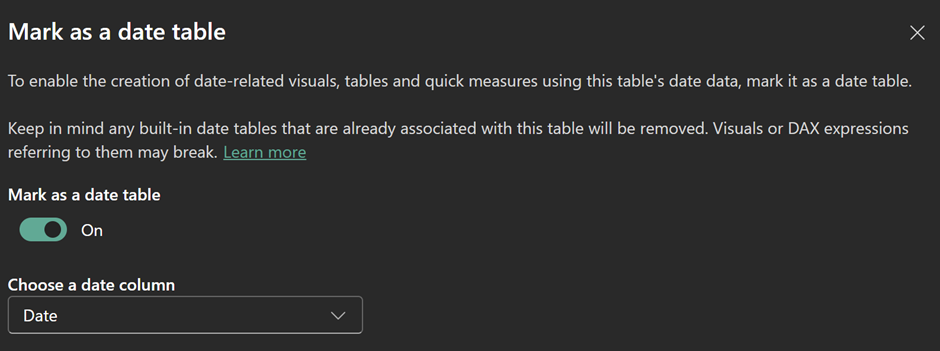

##### **Hierarchies**

You can use hierarchies as one source to help you find detail in dimension tables. These hierarchies form through natural segments in your data. Role-playing dimensions have multiple valid relationships with fact tables, meaning that the same dimension can be used to filter multiple columns or tables of data.

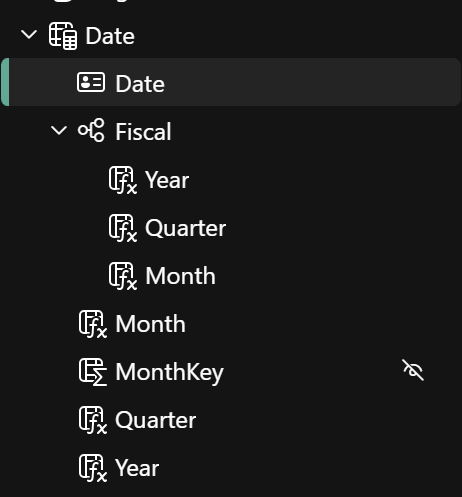


##### **Parent-child Hierarchies**

YIn the following example, you have an employee table within the database that tells you important information about the employees, their managers, and their IDs. The Manager column determines the hierarchy and is therefore the parent, while the "children" are the employees. 

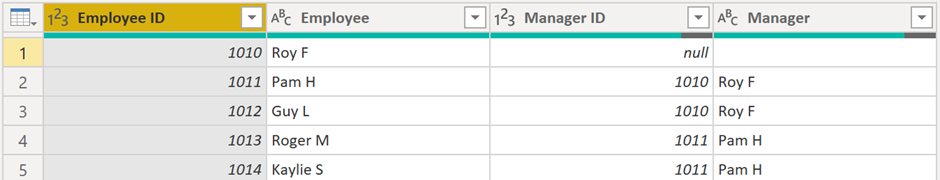

For this example, you want to be able to see all levels of this hierarchy. Power BI does not default to showing you all levels of the hierarchy, so it is your responsibility to ensure that you see all levels of this hierarchy or "flatten" it so that you can see more data granularity.

The process of viewing multiple child levels based on a top-level parent is known as flattening the hierarchy. In this process, you are creating multiple columns in a table to show the hierarchical path of the parent to the child in the same record. You will use `PATH()`, a simple DAX function that returns a text version of the managerial path for each employee, and `PATHITEM()` to separate this path into each level of managerial hierarchy.

While on the table, go to the Modeling tab and select New Column. In the resulting formula bar, enter the following function, which creates the text path between the employee and manager. This action creates a calculated column in DAX.

`Path = PATH(Employee[Employee ID], Employee[Manager ID])`

The completed path between the employee and the manager appears in the new column, as shown in the following screenshot.

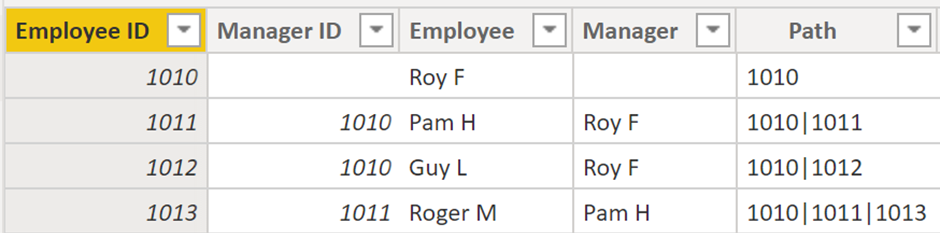

To flatten the hierarchy, you can separate each level by using the `PATHITEM()` function. To view all three levels of the hierarchy separately, you can create four columns in the same way that you did previously, by entering the following equations. You will use the `PATHITEM()` function to retrieve the value that resides in the corresponding level of your hierarchy.

- `Level 1 = PATHITEM(Employee[Path],1)`
- `Level 2 = PATHITEM(Employee[Path],2)`
- `Level 3 = PATHITEM(Employee[Path],3)`

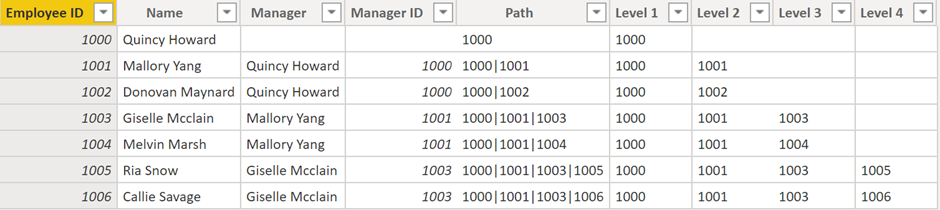

Now, you can create a hierarchy on the Fields pane, as you did previously. Right-click Level 1, because this is the first hierarchy level, and then select New Hierarchy. Then, drag and drop Level 2 and Level 3 into this hierarchy.


#### **Cardinality**

Cardinality is a term that is used to describe the uniqueness of the values in a column. A column that has a lot of repeated values in its range (unique count is low) will have a low level of cardinality. Conversely, a column that has a lot of unique values in its range (unique count is high) will have a high level of cardinality. 

Cardinality is also used in the context of the relationships between two tables, where it describes the direction of the relationship.

- **Many-to-one (\*:1) or one-to-many (1: \*)** relationship describes the directionality between fact and dimension tables. It is the most common type of directionality and is the Power BI default when you are automatically creating relationships.
- **One-to-one (1:1)** relationship is not recommended because this relationship stores redundant information and suggests that the model is not designed correctly. It is better practice to combine the tables.
- **Many-to-many (.)** relationship is not recommended; a lack of unique values introduces ambiguity, and your users might not know which column of values is referring to what.

#### **Cross-filter Direction**

Data can be filtered on one or both sides of a relationship. 

1. With a **single cross-filter direction**: Only one table in a relationship can be used to filter the data. For instance, Table 1 can be filtered by Table 2, but Table 2 cannot be filtered by Table 1. For a one-to-many or many-to-one relationship, the cross-filter direction will be from the "one" side, meaning that the filtering will occur in the table that has many values. Follow the direction of the arrow on the relationship between your tables to know which direction the filter will flow. You typically want these arrows to point to your fact table.

2. With **both cross-filter directions** or **bi-directional cross-filtering**: One table in a relationship can be used to filter the other. For instance, a dimension table can be filtered through the fact table, and the fact tables can be filtered through the dimension table. You might have lower performance when using bi-directional cross-filtering with many-to-many relationships.

You should not enable bi-directional cross-filtering relationships unless you fully understand the ramifications of doing so. Enabling it can lead to ambiguity, over-sampling, unexpected results, and potential performance degradation.


#### **Role-playing Dimensions**

When two model tables have multiple relationships, it could be because your model has a role-playing dimension. For example, if you have a table named `Sales` that includes two date columns, `OrderDateKey` and `ShipDateKey`, both columns are related to the `Date` column in the `Date` table. In this case, the `Date` table is described as a role-playing dimension because it could play the role of order date or ship date.

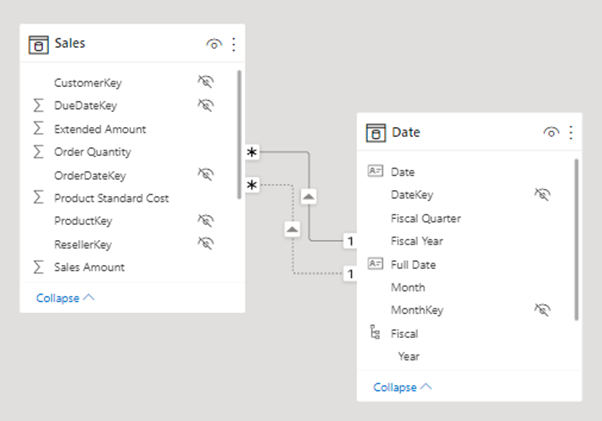

Microsoft Power BI models only allow one active relationship between tables, which in the model diagram is indicated as a solid line. The active relationship is used by default to propagate filters, which in this case would be from the `Date` table to the `OrderDateKey` column in the `Sales` table. Any remaining relationships between the two tables are inactive. In a model diagram, the relationships are represented as dashed lines. 

Inactive relationships are only used when they're expressly requested in a calculated formula by using the `USERELATIONSHIP()` DAX function.

Perhaps a better model design could have two date tables, each with an active relationship to the `Sales` table. Thus, report users can filter by order date or ship date, or both at the same time. A calculated table can duplicate the `Date` table data to create the `Ship Date` table. A calculated table only duplicates data; it doesn't duplicate any model properties or objects like column visibility or hierarchies. You'll need to set them up for the new table, if required.

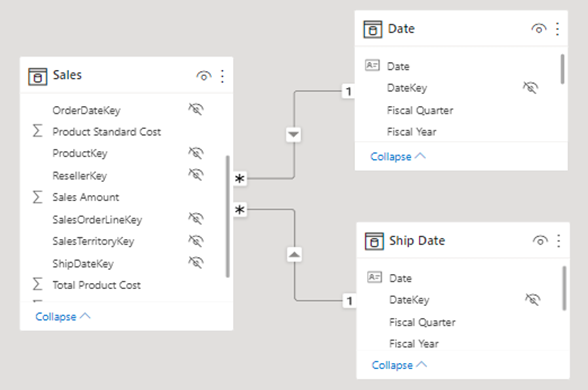



## **Storage Modes**

Each Power BI model table (except calculated tables) has a storage mode property. The storage mode property can be either Import, DirectQuery, or Dual, and it determines whether table data is stored in the model.

### **Import Mode**

Import mode is the default for creating new Power BI reports. The Import mode allows you to create a local Power BI copy of your semantic models from your data source. You can use all Power BI service features with this storage mode, including Q&A and Quick Insights. Data refreshes can be scheduled or on-demand. 

#### **Advantages**
Import models are the most frequently developed model framework because there are many benefits. 
- Support all Power BI data source types, including databases, files, feeds, web pages, dataflows, and more.
- Can integrate source data. For example, one table sources its data from a relational database while a related table sources its data from a web page.
- Support calculated tables.
- Support all DAX and Power Query (M) functionality.
- Deliver the best query performance. That’s because the data cached in the model is optimized for analytic queries (filter, group, and summarize) and the model is stored entirely in memory.


#### **Limitations**
Despite the many compelling benefits, there are limitations of import models that you must bear in mind. Limitations are related to model size and data refresh.

**Model Size**

Power BI imposes dataset size restrictions, which limit the size of a model. When you publish the model to a shared capacity, there’s a 1-GB limit per dataset. There are numerous data reduction techniques that you can apply, including:
- Remove unnecessary columns
- Remove unnecessary rows
- Group by and summarize to raise the grain of fact tables
- Optimize column data types with a preference for numeric data
- Preference for custom columns in Power Query instead of calculated columns in the model
- Disable Power Query query load
- Disable auto date/time
- Use DirectQuery table storage, as described in later units of this module.

**Data Refresh**

Imported data must be periodically refreshed. Dataset data is only as current as the last successful data refresh. To keep data current, you set up scheduled data refresh, or report consumers can perform an on-demand refresh.
Power BI imposes limits on how often scheduled refresh operations can occur. It’s up to eight times per day in a shared capacity, and up to 48 times per day in a dedicated capacity.



### ***DirectQuery* Mode**

The *DirectQuery* option is useful when you don't want to save local copies of your data because your data won't be cached. Instead, you can query the specific tables that you'll need by using native Power BI queries, and the required data will be retrieved from the underlying data source. Essentially, you're creating a direct connection to the data source. Using this model ensures that you're always viewing the most up-to-date data, and that all security requirements are satisfied. Additionally, this mode is suited for when you have large semantic models to pull data from. Instead of slowing down performance by having to load large amounts of data into Power BI, you can use *DirectQuery* to create a connection to the source, solving data latency issues as well.


#### **Advantages**
There are several benefits to developing a DirectQuery model.
- Model large or fast-changing data sources
- DirectQuery is also useful when the source database enforces row-level security (RLS). Instead of replicating RLS rules in your Power BI model, the source data base can enforce its rules. 
- If your organization has security policies that restrict data leaving their premises, then it isn’t possible to import data. A DirectQuery model that connects to an on-premises data source may be appropriate.



#### **Limitations**
There are many limitations related to DirectQuery models that you must bear in mind. Here are the main limitations:
- Not all data sources are supported. Typically, only major relational database systems are supported. Power BI datasets and Azure Analysis Services models are supported too.
- All Power Query (M) transformations are not possible, because these queries must translate to native queries that are understood by source systems. So, for example, it’s not possible to use pivot or unpivot transformations.
- Analytic query performance can be slow, especially if source systems aren’t optimized (with indexes or materialized views), or there are insufficient resources for the analytic workload.
- Analytic queries can impact on source system performance. It could result in a slower experience for all workloads, including OLTP operations.

When there’s a justification to develop a DirectQuery model, you can mitigate some limitations. You can optimize the source database to ensure the expected analytic query workload performs well. Specifically, you can create indexes and materialized views, and ensure the database has sufficient resources for all workloads.




### **Dual Mode**

In Dual mode, you can identify some data to be directly imported and other data that must be queried. Any table that is brought into your report is a product of both Import and DirectQuery modes. Using the Dual mode allows Power BI to choose the most efficient form of data retrieval.

The dual storage mode is between Import and DirectQuery. it is a hybrid approach, Like importing data, the dual storage mode caches the data in the table. However, it leaves it up to Power BI to determine the best way to query the table depending on the query context. 
> Example
1. `Sales` must be Refreshed in near real time so it would be "Direct Query" 
2. `SalesAggregate` is once per week so "Import" (performance also required) 
3. Both `Date` and `Customer` has relationship with both `Sales` and `SalesAggregate` tables so "Dual" because to support performance for DirectQuery(`Sales`) and Import(`SalesAggregate`)


#### **Advantages**
There are several benefits to developing a composite model.
- Composite models provide you with design flexibility. You can choose to integrate data using different storage modes, striking the right balance between imported data and pass-through data. 
- Composite models can also boost the performance of a DirectQuery model by providing Power BI with opportunity to satisfy some analytic queries from imported data. Querying cached data almost always performs better than pass-through queries.

#### **Limitations**
There are several limitations related to composite models.
- Import storage mode tables still require periodic refresh. Imported data can become out of sync with DirectQuery sourced data, so it’s important to refresh it periodically.
- When an analytic query must combine imported and DirectQuery data, Power BI must consolidate source group query results, which can impact performance. To help avoid this situation for higher-grain queries, you can add import aggregation tables to your model (or enable automatic aggregations) and set related dimension tables to use dual storage mode. 
- Relationships between tables from different source groups are known as limited relationships. A model relationship is limited when the Power BI can’t determine a “one” side of a relationship. 





## **Power Query**

The Data Source Settings in the Power Query interface supports editing permissions, clearing permissions, and modifying the path of the data source file. Any structural changes to a file, such as adding, removing, or renaming columns are not supported by the Data Source Settings in the Power Query interface.

### **Shaping Methods**

#### **Promote headers**
```python
df = pd.read_csv('titanic.csv', header=1)
```
```sql
SELECT Name, Sex, Ticket, Cabin, PassengerId, Age, Fare
FROM titanic
```

#### **Rename columns**
```python
df.rename(columns={'Name': 'PassengerName', 'Sex': 'Gender'}, inplace=True)
```
```sql
SELECT Name AS PassengerName, Sex AS Gender, Ticket, Cabin, PassengerId, Age, Fare
FROM titanic
```

#### **Remove top rows**
```python
df = df.iloc[n:]
```
```sql
WITH CTE AS (
    SELECT Name AS PassengerName, Sex AS Gender, Ticket, Cabin, PassengerId, Age, Fare,
           ROW_NUMBER() OVER (ORDER BY PassengerId) AS RowNum
    FROM titanic
)
SELECT PassengerName, Gender, Ticket, Cabin, PassengerId, Age, Fare
FROM CTE
WHERE RowNum > 2
```

#### **Remove columns**
```python
df.drop(columns=['Ticket', 'Cabin'], inplace=True)
```
```sql
SELECT Name AS PassengerName, Sex AS Gender, PassengerId, Age, Fare
FROM titanic
```

#### **Unpivot columns**
```python
df_unpivot = df.melt(
    id_vars=['PassengerId', 'PassengerName'], 
    value_vars=['Age', 'Fare'], 
    var_name='Variable',
    value_name='Value'
    )
```

#### **Pivot columns**
```python
df_pivot = df_unpivot.pivot(
    index=['PassengerId', 'PassengerName'], 
    columns='Variable', 
    values='Value'
    ).reset_index()
```


### **Simplification Methods**

#### **Replace values** 
```python
df['PassengerName'] = df['PassengerName'].replace({'Johhny':'John','Becky':'Beck'})
```
```sql
SELECT 
    CASE 
        WHEN Name = 'Johhny' THEN 'John'
        WHEN Name = 'Becky' THEN 'Beck'
        ELSE COALESCE(Name, 'Unknown')
    END AS PassengerName
FROM titanic
```

#### **Replace null values** 
```python
df['PassengerName'].fillna('Unknown', inplace=True)
```
```sql
SELECT 
    COALESCE(Name, 'Unknown') AS PassengerName
FROM titanic
```

#### **Remove duplicates**
```python
df['PassengerName'].drop_duplicates(inplace=True)
```
```sql
SELECT DISTINCT PassengerName
FROM (
    SELECT 
        CASE 
            WHEN Name = 'Johhny' THEN 'John'
            WHEN Name = 'Becky' THEN 'Beck'
            ELSE COALESCE(Name, 'Unknown')
        END AS PassengerName
    FROM titanic
) AS Subquery
```

### **Profiling Data**
By default, Power Query examines the first 1000 rows of your data set. To change this, select the profiling status in the status bar and select Column profiling based on entire data set. 


### **Data Types**

You can change the data type of a column in two places: in Power Query Editor and in the Power BI Desktop Report view by using the column tools. It is best to change the data type in the Power Query Editor before you load the data.


### **Joining Tables**
You can combine tables into a single table in the following situations:
- Too many tables exist, making it difficult to navigate an overly complicated semantic model.
- Several tables have a similar role.
- A table has only a column or two that can fit into a different table.
- You want to use several columns from different tables in a custom column.

In the Query Properties window, uncheck the Enable Load To Report checkbox. Disabling the load means it will not load as a table to the data model. 


### **Adding Columns**

#### **Columns From Examples**
 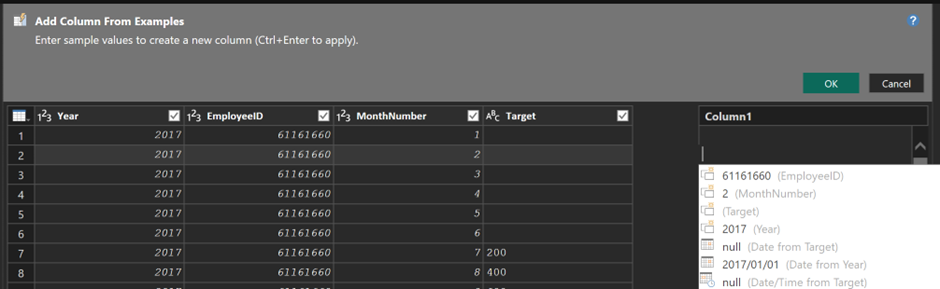

#### **Custom Column**
 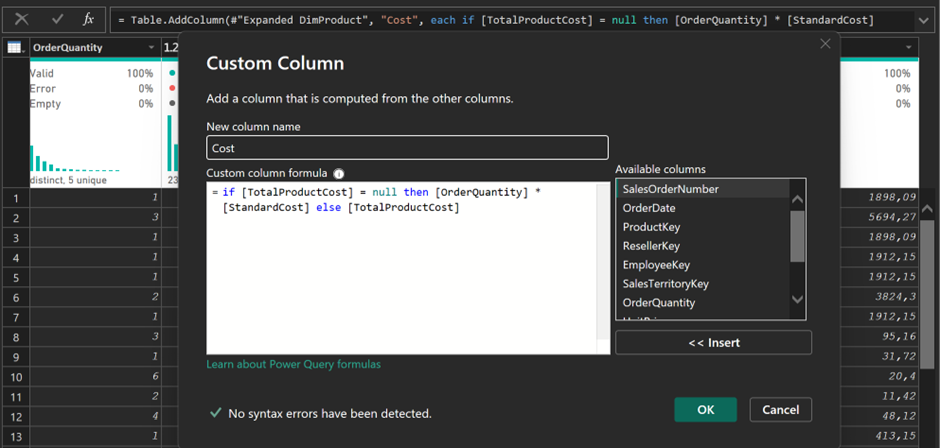

You can also delete columns in the next step after they are used


## **Data Analytics Expressions (DAX)**

https://learn.microsoft.com/en-us/dax/ 

A DAX formula consists of expressions that return a result. The result is either a table object or a scalar value. Calculated table formulas must return a table object; calculated column and measure formulas must return a scalar value (single value).
Because DAX originated with the Power Pivot add-in for Microsoft Excel 2010, over 80 functions are available that can also be found in Excel. It was a deliberate design strategy by Microsoft to ensure that Excel users can quickly become productive with DAX. However, many functions exist that you won't find in Excel because they're specific to data modelling.

### **Analytic Query**

An analytic query is a query that produces a result from a semantic model. Each Power BI visual, in the background, submits an analytic query to Power BI to query the model. The analytic query is written as a Data Analysis Expressions (DAX) query statement. However, you don't need to write a native DAX statement; you only need to configure report visuals by mapping semantic model fields.

An analytic query has three phases that are implemented in the following order:
1. Filtering, or slicing, targets the data of relevance. In Power BI reports, filters can be applied to three different scopes: 
    - the entire report 
    - a specific page
    - a specific visual
Filtering is also applied in the background when row-level security (RLS) is enforced. Each report visual can inherit filters or have filters directly applied to it.
2. Grouping, or dicing, divides query results into groups.
3. Summarizing produces a single value result. Typically, numeric columns are summarized by using summarization methods (sum, count, and many others). These methods are simple summarizations. More complex summarizations, like a percent of grand total, can be achieved by defining measures that are written in DAX.


### **Calculated Table**

The formula can duplicate or transform existing model data, or create a series of data, to produce a new table. Calculated table data is always imported into your model, so it increases the model storage size and can prolong data refresh time. Tables that comprise only visible measures are automatically listed at the top of the list.


#### **Creating Dates**
- The `CALENDAR(start_date, end_date)` function returns a contiguous range of dates based on a start and end date that are entered as arguments in the function. 
- Alternatively, the `CALENDARAUTO()` function returns a contiguous, complete range of dates that are automatically determined from your semantic model. The starting date is chosen as the earliest date that exists in your semantic model, and the ending date is the latest date that exists in your semantic model plus data that has been populated to the fiscal month that you can choose to include as an argument in the `CALENDARAUTO()` function. The fiscal year end month (optional) is an integer (1-12) representing the last month of your fiscal year. If omitted, Power BI will default to December (12), making January the start of the fiscal year.

#### **Parameters**
You can create variables for your reports, interact with the variable as a slicer, and visualize and quantify different key values in your reports. Create a parameter on the Modeling tab in Power BI Desktop. When you select it, a dialog box appears where you can configure the parameter.
1. To create a parameter, select New parameter from the Modeling tab in Power BI Desktop
2. Choose either Fields or Numeric range.

### **Calculated Column**

You can write a DAX formula to add a calculated column to any table in your model. The formula is evaluated for each table row and it returns a single value. When added to an Import storage mode table, the formula is evaluated when the semantic model is refreshed, and it increases the storage size of your model. When added to a DirectQuery storage mode table, the formula is evaluated by the underlying source database when the table is queried.

There are three techniques that you can use to add columns to a model table:
- Add columns to a view or table (as a persisted column), and then source them in Power Query. This option only makes sense when your data source is a relational database and if you have the skills and permissions to do so. 
- Add custom columns (using M) to Power Query queries.
- Add calculated columns (using DAX) to model tables.


#### **Row Context**
The formula for a calculated column is evaluated for each table row. Furthermore, it's evaluated within row context, which means the current row. You'll find that Microsoft Excel has the same concept for working with formulas in Excel tables.

However, row context doesn't extend beyond the table. If your formula needs to reference columns in other tables, you have two options:
- If the tables are related, directly or indirectly, you can use the `RELATED` or `RELATEDTABLE` function. The `RELATED` function retrieves the value at the one-side of the relationship, while the `RELATEDTABLE` retrieves values on the many-side. The `RELATEDTABLE` function returns a table object.
```dax
Product Name = RELATED(Products[Product Name])
```
```dax
Total Sales = SUMX(RELATEDTABLE(Sales), Sales[Sales Amount])
```
- When the tables aren't related, you can use the `LOOKUPVALUE` function. (Technically, should almost never be the case)
```dax
Product Description = 
LOOKUPVALUE(
    ProductDetails[Product Desc], 
    ProductDetails[ProductID], Sales[ProductID]
)
```

Generally, try to use the `RELATED` function whenever possible. It will usually perform better than the `LOOKUPVALUE` function due to the ways that relationship and column data is stored and indexed.


#### **Hierarchies**
- The `PATH(child, parent)` function creates a delimited string representing the lineage or hierarchy of a particular row in a parent-child relationship.
- The `PATHITEM(path_column, position, [type])` function retrieves a specific item (level) from a hierarchy string created by `PATH`. `type (optional)` specifies the data type of the output: 
    - 1 or INTEGER for numeric output.
    - 0 or TEXT for text output (default).

### **Measures**

Measures in Microsoft Power BI models are either implicit or explicit. Implicit measures are automatic behaviours that allow visuals to summarize model column data. Explicit measures, also known simply as measures, are calculations that you can add to your model. 

Additionally, no such concept as a calculated measure exists in tabular modelling. The word calculated is used to describe calculated tables and calculated columns, which distinguishes them from tables and columns that originate from Power Query. Power Query doesn't have the concept of an explicit measure.

Measures are designed to summarize model data; they can't be used to group data. However, measures can be used to filter data in one special case: to use a measure to filter a visual when the visual displays the measure and the filter is a visual-level filter. When used in this way, a measure filter is applied after the analytic query has summarized data. This process is done to eliminate groups where the measure filter condition isn't true. (For those who are familiar with SQL syntax, a measure that used to filter a visual is like the `HAVING` clause in a `SELECT` statement.)

#### **Implicit Measures**

The most significant limitation of implicit measures is that they only work for simple scenarios, meaning that they can only summarize column values that use a specific aggregation function.

#### **Explicit Measures**

The most significant limitation of implicit measures is that they only work for simple scenarios, meaning that they can only summarize column values that use a specific aggregation function.

You can write a DAX formula to add a measure to any table in your model. The formula is concerned with achieving summarization over model data. Like a calculated column, the formula must return a single value. Unlike calculated columns, which are evaluated at data refresh time, measures are evaluated at query time. Their results are never stored in the model.

#### **Quick Measures**

Microsoft Power BI Desktop includes a feature named Quick Measures. This feature helps you to quickly perform common, powerful calculations by generating the DAX expression for you.

Time intelligence functions have performance implications and are disabled for quick measures against DirectQuery tables. Mathematical operations, aggregate per category, and X-functions are all supported against DirectQuery.

### **DAX Functions**

#### **Division**
You can use the `DIVIDE()` function to achieve division. You must pass in numerator and denominator expressions. Optionally, you can pass in a value that represents an alternate result.

```dax
Average Price = DIVIDE(Sales[Sales Amount], Sales[Quantity Sold], 0)
```

#### **Concatenation**
Use the ampersand `&` character to connect, or concatenate, two text values to produce one continuous text value. 

```dax
FullName = Employees[FirstName] & " " & Employees[LastName]
```

#### **Formatting**
The `FORMAT()` function is used to format values (like numbers and dates) as strings, based on a specified format pattern. It’s particularly useful in Power BI to customize the appearance of data in reports, such as controlling the display of currency, percentages, dates, and more.

```dax
Month = FORMAT('Date'[Date]), "YYYY MMM")
```

#### **Top N Values**
The `TOPN` function in DAX returns the top (or bottom) rows of a table based on a specified expression for ranking. It is commonly used to filter or retrieve the highest or lowest values in a dataset according to a measure or column. Syntax: `TOPN(<n_value>, <table>, <order_by_expression> [, <order>])`

> Example 1: This returns the top 5 products from the Product table based on the total sales amount in descending order.
```dax
Top 5 Products by Sales = 
TOPN(
    5,
    Product,
    SUM(Sales[Sales Amount]),
    DESC
)
```

> Example 2: The TOPN function filters the Customer table to the top 10 customers based on their total sales. The SUMX function then calculates the total sales for those 10 customers.
```dax
Top Customers Sales = 
SUMX(
    TOPN(
        10,
        Customer,
        SUM(Sales[Sales Amount]),
        DESC
    ),
    Sales[Sales Amount]
)
```

#### **Displaying Results**
The `HASONEVALUE` function checks if a column has exactly one distinct value in the current filter context. It is commonly used in measures to control behavior when aggregating or working with filtered data. It returns `TRUE` if the column has exactly one distinct value in the current filter context.
```dax
Region Sales = 
IF(
    HASONEVALUE(Sales[Region]),
    SUM(Sales[Sales Amount]),
    "Please select a single region"
)
```




#### **Dynamic Titles**
Dynamic titles in Power BI adjust automatically based on user interactions with slicers, filters, or visuals. They are commonly implemented using DAX measures and are used to make dashboards more interactive and user-friendly. `ISFILTERED` checks whether a specific column is currently being filtered in the filter context. It returns `TRUE` if the column is filtered (e.g., by slicers, visuals, or cross-filtering) and `FALSE` if it is not filtered (i.e., all values are visible). Essentially, `ISFILTERED` detects the existence of a filter, regardless of how many values are filtered and `HASONEVALUE` ensures a single value is filtered, often used for precise selection logic.

```dax
Dynamic Title = 
IF(
    HASONEVALUE(Sales[Region]),
    "Sales for " & VALUES(Sales[Region]),
    IF(
        ISFILTERED(Sales[Region]),
        "Multiple Regions Selected",
        "All Regions"
    )
)
```

#### **Changing Filter Context**
The `CALCULATE` function modifies the filter context of a calculation, allowing you to apply filters dynamically to a measure or expression. It is one of the most important and versatile functions in DAX and is often considered the foundation for creating most measures in Power BI. Synatx: `CALCULATE(<expression>, <filter1>, <filter2>, ...)`. Essentially, it performs the calculation specified in `<expression>` and temporarily overrides or adds filters for the calculation.

When you have multiple filters, they're evaluated by using the `AND` logical operator, which means that all conditions must be TRUE at the same time.

>Example: Sales above 1000. Sales in the year 2024. Product category is "Electronics" from a related table Prodcut.
```dax
High-Value Sales in 2024 = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    Sales[Sales Amount] > 1000,
    Sales[Year] = 2024,
    Product[Category] = "Electronics"
)
```

The `CALCULATETABLE` DAX function performs exactly the same functionality as the `CALCULATE` function, except that it modifies the filter context that's applied to an expression that returns a table object. In this module, the explanations and examples use the CALCULATE function, but keep in mind that these scenarios could also apply to the `CALCULATETABLE` function.

##### **List of Conditions**

> Example: In this next example, the following measure filters the Revenue measure by multiple colors.
```dax
Revenue Red or Blue = 
CALCULATE(
    [Revenue], 
    'Product'[Color] IN {"Red", "Blue"}
    )
```
Notice the use of the `IN` operator followed by a list of color values.

##### **Aggregate & Complex Filters**
Commonly, you'll use the `FILTER` DAX function to apply complex filter conditions, including those that can't be defined by a Boolean filter expression. The `FILTER` function is classed as an iterator function, and so you would pass in a table, or table expression, and an expression to evaluate for each row of that table.

The `FILTER` function returns a table object with exactly the same structure as one that the table passed in. Its rows are a subset of those rows that were passed in, meaning the rows where the expression evaluated as `TRUE`.The syntax is: `FILTER(<table>, <expression>)`. You can also apply multiple conditions in a FILTER expression. 
> Example: : This formula filters the Sales table to include only rows where both the Price is greater than 500 and the Quantity is greater than 10.
```dax
Total Sales (High Price & Quantity) = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    FILTER(Sales, Sales[Price] > AVERAGE(Sales[Price]) && Sales[Quantity] > 10)
)

```
Since `FILTER` works row by row, using it on large tables or in complex expressions can impact performance. Internally, Microsoft Power BI translates Boolean filter expressions to table filter expressions, which is how it translates your Revenue Red measure definition.

```dax
Revenue Red or Blue =
CALCULATE(
    [Revenue],
    FILTER(
        'Product',
        'Product'[Color] in {"Red","Blue"}
    )
)

```

##### **Removing Filters**
The `REMOVEFILTERS` function in DAX is used to clear filters from specific columns, entire tables, or all tables in a model, restoring the data to its unfiltered state within the current filter context. It’s commonly used in combination with functions like `CALCULATE` to override filters applied elsewhere in a report or calculation.


**Specific Column**
- You can use `REMOVEFILTERS` to remove filters on a specific column while keeping other filters intact.
> Example: This will calculate the total sales, ignoring any filters applied to the ProductCategory column in the Product table but keeping other filters, like those on Date, intact.
```dax
Total Sales (Remove Product Filter) = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    REMOVEFILTERS(Product[ProductCategory])
)
```


**Entire Table**

You can remove all filters from an entire table.
> Example: This removes all filters from the Product table, meaning no filter on Product (like ProductCategory or ProductID) will affect the sales calculation, but other table filters (like those on Date) will still apply.
```dax
Total Sales (Remove Product Table Filter) = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    REMOVEFILTERS(Product)
)
```

**All Tables**

To remove all filters from all tables, you can use `REMOVEFILTERS()` with no arguments.
> Example: This removes all filters from the entire model, meaning no filters on any table will affect the sales calculation.

```dax
Total Sales (Remove All Filters) = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    REMOVEFILTERS()
)
```

##### **Preserving Filters**

You can use the `KEEPFILTERS` DAX function as a filter expression in the `CALCULATE` function to preserve filters.
```dax
Revenue Red =
CALCULATE(
    [Revenue],
    KEEPFILTERS('Product'[Color] = "Red")
)
```

#### **Columns in Context**
The `ISINSCOPE()` function is used to determine if a specific column or field is in the current filter context. It returns a TRUE or FALSE value based on whether the column is present in the filter context (such as a visual or a calculation) at the current level of the hierarchy.

> Example: If you want to apply different color formatting to a measure depending on whether it is being viewed at the product level or category level, you can use `ISINSCOPE()` to detect the context and return different values for formatting purposes.
```dax
Sales Format = 
IF(
    ISINSCOPE(Product[Category]),
    "Green",  -- Format as Green when in Category scope
    "Red"  -- Format as Red when in Subcategory scope
)
```
>Example: `ISINSCOPE(Region[Region])`: This checks if the Region column is currently in scope in the filter context. If the user is drilling down to the Region level (i.e., if Region is part of the current context), it will return TRUE. If the Region column is not part of the current context (i.e., if you are looking at a higher level, like a country level), it returns FALSE.

> `IF(ISINSCOPE(Region[Region]), ...)`: If Region is in scope (meaning we are at the region level), the formula proceeds to calculate the percentage. If not, it returns a blank (i.e., no calculation).

> `CALCULATE(SUM(Sales[Sales]), REMOVEFILTERS(Region[Region]))`: It modifies the filter context for the calculation. In this case, it sums the total sales but removes the filter on the Region column. The `REMOVEFILTERS(Region[Region])` part ensures that the sales sum is calculated without any filter applied to the Region column, effectively providing the total sales across all regions.

```dax
Sales % Country = 
IF(  
    ISINSCOPE(Region[Region]),  
    DIVIDE(
        SUM(Sales[Sales]),  
        CALCULATE(  
            SUM(Sales[Sales]),  
            REMOVEFILTERS(Region[Region])  
        ),
    )  
)
```

![image.png](attachment:image.png)

#### **Role-playing Dimensions**
The `USERELATIONSHIP()` function in DAX is used to activate an inactive relationship between two tables in your data model temporarily for the duration of a calculation. This is useful when you have multiple relationships between two tables but only one is active by default. By default, calculations like total sales use the active relationship (Order Date). To calculate total sales by Ship Date, we use `USERELATIONSHIP()`.

```dax
Total Sales by Ship Date = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    USERELATIONSHIP(Sales[Ship Date], Date[Date])
) 
```

#### **Iterator Functions**

By now, you're familiar with single-column summarization functions, including `SUM`, `COUNT`, `MIN`, `MAX`, and others. Each of these functions has an equivalent iterator function that's identified by the "X" suffix, such as `SUMX`, `COUNTX`, `MINX`, `MAXX`, and others. Additionally, specialized iterator functions exist that perform filtering, ranking, semi-additive calculations over time, and more.

`SUMX` and similar functions are known as iterators. They are used to perform calculations row-by-row over a table or an expression, and then return an aggregated result (like a sum, average, or other aggregation). These functions work by iterating over each row of a table, applying an expression, and then aggregating the results. Syntax: `SUMX(<table>, <expression>)`.

Single-column summarization functions, like SUM, are shorthand functions. Internally, Microsoft Power BI converts the SUM function to SUMX. As a result, the following two measure definitions will produce the same result with the same performance.
```dax
Revenue = SUM(Sales[Sales Amount])
```
```dax
Revenue = SUMX(Sales, Sales[Sales Amount])
```

> Example: Calculate the total sales value where the price and quantity of products are multiplied for each row and is greater than 1000. Here, `SUMX` will go row by row in the Sales table, multiply Price and Quantity for each row, and then sum up those results.
```dax
Total Sales = SUMX(Sales, Sales[Price] * Sales[Quantity] > 1000)
```
While `SUMX` and similar functions are used to iterate over rows, `CALCULATE` is used to change the context in which a given expression is evaluated (i.e., modify the filters that apply to the data). `CALCULATE` doesn't iterate over rows but instead modifies the filter context first under which then an expression is evaluated.

Sometimes, you might use both CALCULATE and iterators together. 
> Example: You might want to calculate the total sales for a specific product category, but only for rows where the price is greater than a certain threshold.
```dax
Total Sales for High-Price Products = CALCULATE(
    SUMX(Sales, Sales[Price] * Sales[Quantity]),
    Sales[Price] > 500
)
```



##### **Ranking**
The `RANKX` DAX function is a special iterator function you can use to calculate ranks. Its syntax is as follows: `RANKX(<table>, <expression>[, <value>[, <order>[, <ties>]]])`. Order direction is either ascending or descending. When ranking something favorable, like revenue values, you're likely to use descending order so that the highest revenue is ranked first. When ranking something unfavorable, like customer complaints, you might use ascending order so that the lowest number of complaints is ranked first. When you don't pass in an order argument, the function will use 0 (zero) (for descending order). You can handle ties by skipping rank values or using dense ranking, which uses the next rank value after a tie. When you don't pass in a ties argument, the function will use Skip.

```dax
Product Quantity Rank =
IF(
    HASONEVALUE('Product'[Product]),
    RANKX(
        ALL('Product'[Product]),
        [Quantity],
        ,
        ,
        DENSE
    )
)
```

The `ALL` function is used to return all rows in a model table or values in one or more columns, and it ignores all filters. Therefore, in this case, it returns a table that consists of all Product column values in the Product table. The `RANKX` function must use the `ALL` function because the table visual will group by product (which is a filter on the Product table).

#### **Time Intelligence**
DAX includes several time intelligence functions to simplify the task of modifying date filter context. You could write many of these intelligence formulas by using a `CALCULATE` function that modifies date filters, but that would create more work. 
To work with time intelligence DAX functions, you need to meet the prerequisite model requirement of having at least **one date table** in your model. 

A **date table** is a table that meets the following requirements:
- It must have a column of data type Date (or date/time), known as the date column.
- The date column must contain unique values.
- The date column must not contain BLANKs.
- The date column must not have any missing dates.
- The date column must span full years. A year isn't necessarily a calendar year (January-December).
- The date table must be indicated as a date table.


##### **Summaries Over Time**

**YTD Date Columns**

`DATESYTD` Returns a single-column table that contains dates for the year-to-date (YTD) in the current filter context. This group also includes the `DATESMTD` and `DATESQTD` DAX functions for month-to-date (MTD) and quarter-to-date (QTD). You can pass these functions as filters into the `CALCULATE` function. The year-end date value of "6-30" represents June 30. Notice that it produces a summarization of the revenue amounts from the beginning of the year through to the filtered month.

> Example: Suppose you have a Sales table with a SalesDate column and you want to calculate the total sales for the current year up to today.
```dax
Sales YTD = 
CALCULATE(
    SUM(Sales[Sales]),
    DATESYTD('Date'[Date], "6-30")
)
```

**YTD Expression**

`TOTALYTD` evaluates an expression for YTD in the current filter context. The equivalent QTD and MTD DAX functions of TOTALQTD and `TOTALMTD` are also included. 

```dax
Sales YTD = TOTALYTD(SUM(Sales[Sales]), 'Date'[Date], "6-30")
```

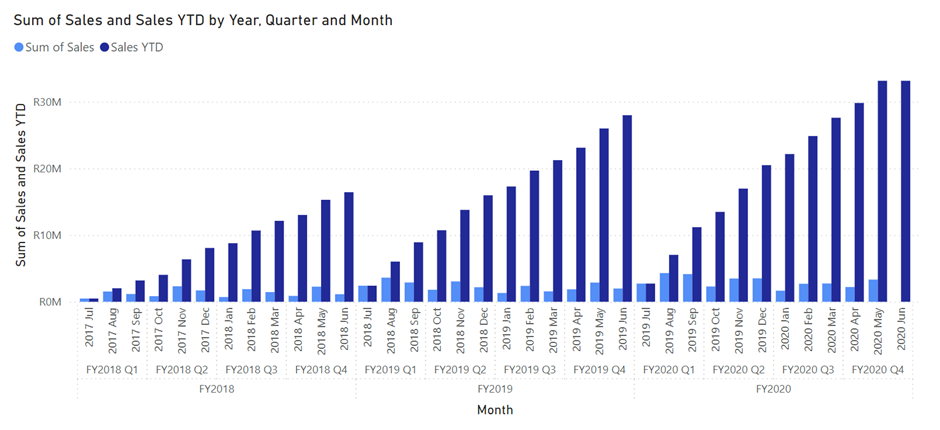

**Range of Date Columns**

`DATESBETWEEN` function returns a table that contains a column of dates that begins with a given start date and continues until a given end date. When the start date is `BLANK`, it will use the first date in the date column. (Conversely, when the end date is `BLANK`, it will use the last date in the date column.) In this case, the end date is determined by the MAX function, which returns the last date in filter context. 

```dax
OrdersLTD =
    CALCULATE(
        DISTINCTCOUNT(Sales[SalesOrderNumber]),
        DATESBETWEEN(
            'Date'[Date],
            BLANK(),
            MAX('Date'[Date])
        )
    )
```
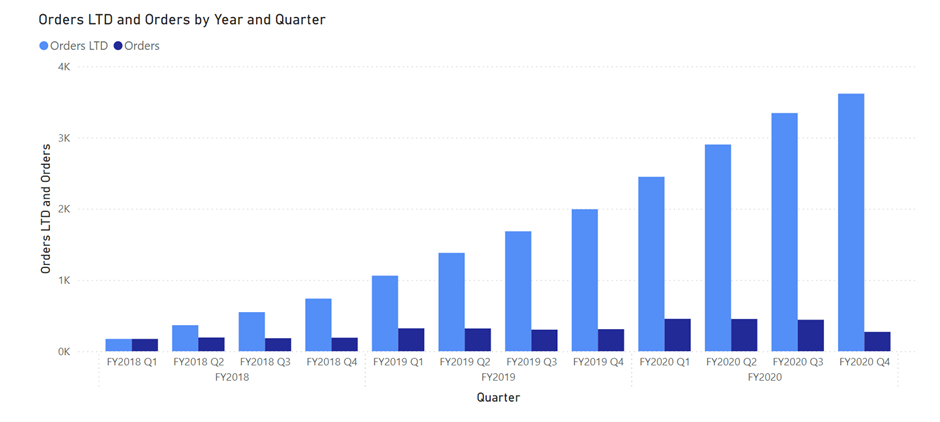

Notice that the `DATESBETWEEN` function includes dates until the first date in filter context minus one. Because Microsoft Power BI internally stores dates as numbers, you can add or subtract numbers to shift a date.

**Custom Interval of Date Columns**

The `DATESINPERIOD` function in DAX is used to return a table of dates that represents a specific range of dates, starting from a given date and extending for a defined period. This function is useful when you want to analyze data over a custom time period (e.g., last 3 months, next 6 weeks, etc.). Syntax: `DATESINPERIOD(<dates>, <start_date>, <number_of_intervals>, <interval>)`. This function is dynamic and useful for creating measures that calculate results over specific time windows relative to a date.

> Example 1: Last 3 Months
```dax
Sales Last 3 Months = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    DATESINPERIOD(Sales[SalesDate], TODAY(), -3, MONTH)
)
```

> Example 2: Next 6 Weeks
```dax
Sales Next 6 Weeks = 
CALCULATE(
    SUM(Sales[SalesAmount]),
    DATESINPERIOD(Sales[SalesDate], TODAY(), 6, WEEK)
)
```

##### **Comparisons Over Time**

**Shift Partial Date Periods**

The `DATEADD` function is a time intelligence function that shifts a set of dates by a specified interval, such as days, months, quarters, or years. It is commonly used to create comparisons over a specific time period, such as moving averages, year-over-year analysis, or period-to-period changes. Syntax: `DATEADD(<dates>, <number_of_intervals>, <interval>)`

> Example: To calculate sales for the same period last year.
```dax
Sales Last Year = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    DATEADD('Date'[Date], -1, "YEAR")
)
```

> Example: To calculate sales for the last three months. When you want to calculate rolling time periods like moving averages or rolling totals.
```dax
Sales Last 3 Months = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    DATEADD('Date'[Date], -3, "MONTH")
)
```

Many helper DAX functions for navigating backward or forward for specific time periods, all of which returns a table of dates. These helper functions include `NEXTDAY`, `NEXTMONTH`, `NEXTQUARTER`, `NEXTYEAR`, and `PREVIOUSDAY`, `PREVIOUSMONTH`, `PREVIOUSQUARTER`, and `PREVIOUSYEAR`.


**Shift Full Date Periods**

`PARALLELPERIOD` shifts the range of dates by a defined number of intervals (e.g., months, quarters, or years) in either direction (past or future). It’s more flexible than ``SAMEPERIODLASTYEAR`` because you can move forward or backward by any number of intervals. Unlike `DATEADD` it cannot handle incomplete date ranges (e.g., partial months or years) but it is computationally faster than `DATEADD`. Syntax: `PARALLELPERIOD(<dates>, <number_of_intervals>, <interval>)`

> Example: Sales for Two Quarters Ahead.
```dax
Sales Next Two Quarters = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    PARALLELPERIOD('Date'[Date], 2, "QUARTER")
)
```



**Shift Full Year Periods**

`SAMEPERIODLASTYEAR` returns the exact same date range in the previous year. It’s a specialized function primarily used for year-over-year comparisons.

> Example: Returns sales for the same period (day, month, or year range) in the previous year.
```dax
Sales Last Year = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    SAMEPERIODLASTYEAR('Date'[Date])
)
```



### **DAX Syntax**


- When you reference a table in a formula, officially, the table name is enclosed within single quotation marks. 
    > 'Employee Headcount'
    
    However, single quotation marks can be omitted when both of the following conditions are true:
    1. The table name does not include embedded spaces. e.g. `Sales`
    2. The table name isn't a reserved word that's used by DAX. All DAX function names and operators are reserved words. `Date` is a DAX function name, which explains why, when you are referencing a table named `'Date'`, that you must enclose it within single quotation marks.

- When you reference a column in a formula, the column name must be enclosed within square brackets. 
    > [Employee Name]
- Optionally, it can be preceded by its table name. 
    > Headcount[Employee Name] 
    
    Because column names are unique within a table but not necessarily unique within the model, you can disambiguate the column reference by preceding it with its table name. This disambiguated column is known as a fully qualified column. Some DAX functions require passing in fully qualified columns.

- It is recommended that you never precede a measure reference with its table name. When a measure references one or more measures, it's known as a compound measure.
    > [Total Sales]

- Use spaces between operators.
- Use tabs to indent nested function calls.
- Use carriage returns to separate function arguments, especially when it's too long to fit on a single line. Formatting in this way makes it simpler to troubleshoot, especially when the formula is missing a parenthesis. In the formula bar, to enter a carriage return, press `Shift+Enter`. Pressing Enter alone will commit your formula.
- Err on the side of too much whitespace than too little.




## **Visuals**

### **Categorical Visuals**

Often, **bar charts** or **column charts** are good choices when you need to show data across multiple categories. Selecting which type depends on the number of categories and the kind of information that you want to visualize. For example, if many category values are available, you should avoid selecting a visual where colour is used to split the data, such as a stacked bar chart with a category legend. Instead, use the category dimension on the axis of a bar chart.

Additionally, you should avoid a line chart with a categorical X-axis because the line implies a relationship between elements that might not exist. In the following example, notice that the line chart visual implies a relationship between the product categories on the X-axis.


### **Time Series Visuals**

Always use a **line chart** or **column chart** to show values over time. The X-axis should present time, sorted from earliest to latest periods (left to right). Line charts work well with a consistent flow of data, such as when sales are recorded for every period. If no sales are recorded for some periods, the line chart visual will fill such gaps with a straight line that connects the values of the previous and next periods. If missing values are a possibility, a column chart might be a better visual choice because it will help to avoid the interpretation of a non-existent trend. Other Power BI core visuals that you can use for time series data include:
- Stacked column chart
- Area chart
- Line and stacked column chart
- Ribbon chart, which has the added benefit of showing rank changes over time


### **Proportional Visuals**

Proportional visuals show data as part of a whole. They effectively communicate how a value is distributed across a dimension. **Column chart** and **bar chart** visuals work well for visualizing proportions across multiple dimensions. Other Power BI core visuals that you can use for proportional visualization include:
- 100% Stacked Column chart
- Funnel chart
- Tree map
- Pie chart
- Doughnut chart



### **Numeric Visuals**

Often presented by **card visuals**, numeric values show high-level callouts that demand immediate attention. They can be powerful in dashboard and analytical reports because they communicate important data quickly.


### **Grid Visuals**

Often overlooked, **tables** and **matrices** can effectively convey a lot of detailed information. Tables have a fixed number of columns, and each column can express grouped or summarized data. Matrices can have groups on columns and rows. Adding conditional formatting options, such as background colours, font colours, or icons, can enhance values with visual indicators. Matrix and table visuals support conditional formatting. Gauge chart, scatter chart, and treemap do not support conditional formatting.

This extra context supports simple report consumption and can bring balance to a report page. Additionally, matrices provide one of the best experiences for hierarchical navigation. They allow users to drill down, on the columns or rows, to discover detailed data points of interest.



### **Performance Visuals**

Communicating performance involves describing a value and its comparison to a target. Any difference between the value and target is its variance, which can be favourable or unfavourable. Colour or icons can convey status. Other Power BI core visuals that you can use to show performance include:
- Gauge
- KPI
- Table, with conditional formatting
- Matrix, with conditional formatting



### **Geospatial Visuals**
When a semantic model has geospatial information, it can be conveyed by using map visuals. Power BI includes several core map visuals. Each visual offers various formatting options that, when appropriately applied, can help highlight geospatial data. 


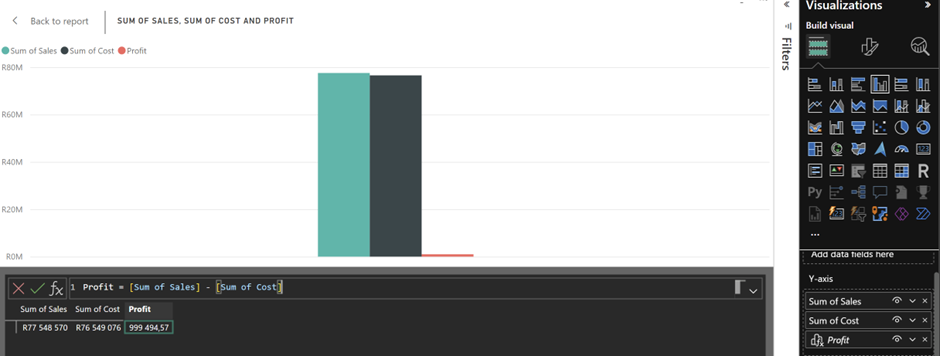
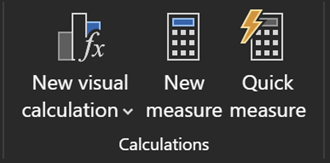

### **Other Visuals**

- A **waterfall visualization** is a chart that displays a running total, with the initial and the final value columns starting on the horizontal axis while the intermediate values are floating columns. 
- To create a **custom R or Python visual** by using Power BI Desktop, you first need to install R or Python on your computer. Configuring global R scripting options in Power BI Desktop might be required once you install R or Python on your computer. Enabling the script visuals option in the Visualization pane of Power BI Desktop is done once R is installed and configured using the global R or Python script options in Power BI Desktop. Creating a custom R or Python visual by using Power BI Desktop has no dependency on enabling preview features.

### **Visual Calculations**
Visual calculations are a simple way to add calculations to your Power BI report. They're DAX calculations defined on a visual and are defined visually. Compared to measures, the DAX required is easier to write, understand, and maintain. 

DAX in visual calculations works differently from other calculation options. The formula isn't stored in the model, but on the visual itself. This means they can only refer to what's on the visual. If you need to use something from the model, you must add it to the visual first. This approach simplifies things by avoiding the complexity of filter context and the model.
Creating a visual calculation is straightforward - select a visual and choose New calculation. The visual calculation window consists of three major sections, as shown from top to bottom in the following image:

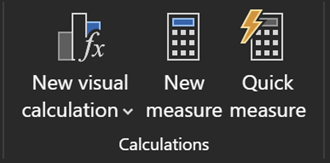

The visual preview which shows the visual you're working with. A formula bar where you can add visual calculations. The visual matrix which shows the data in the visual, and displays the results of visual calculations as you add them. Any styling or theming you apply to your visual isn't applied to the visual matrix.

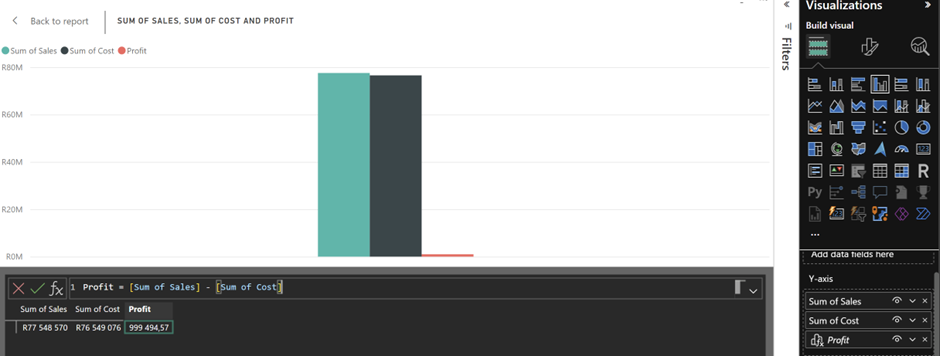

In visual calculations edit mode, you can hide fields from the visual just like you can hide columns and tables in the modelling view. For example, if you wanted to only show the Profit visual calculation, you can hide Sales Amount and Total Profit cost from view.


### **Sorting Columns by Other Columns**

You can also sort a column by the value of another column. On the Column Tools contextual ribbon, from inside the Sort group, select Sort by Column, and then select the relevant sort column.

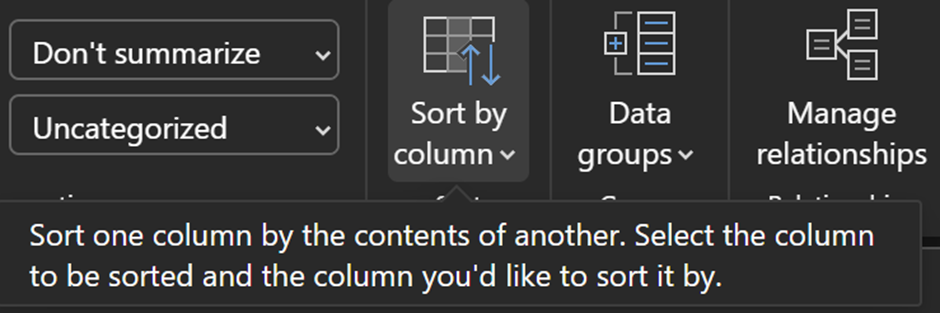


## **Filtering Techniques**


Filtering can occur at five different levels of a Microsoft Power BI report:
1. **Semantic model (RLS)**: The semantic model can enforce row-level security to restrict access to a subset of data, and different users will see different data.
2. **Report**: The top level is the report, the second level comprises its pages, while the third level comprises report objects, which consist of visuals and elements. In the Filters pane, you can add a filter to any of these levels. The Filters on all pages section defines report-level filters, which apply to all report pages and visuals. Report-level filters are global filters.
3. **Page**: The Filters on this page section defines page-level filters, which apply to all visuals on a specific page, adding to any existing report-level filters.
4. **Visual**: The Filters on this visual section defines visual-level filters. This section is only visible when one visual is in focus because visual-level filters apply only to a single visual; they add to any existing report-level and page-level filters. Unlike report and page-level filters, a visual-level filter can filter by using a measure. When a measure filters a visual, it's used to eliminate groups. For example, consider a column chart visual that groups by store. A measure filter could eliminate groups (stores) where the total store sales are less than a certain amount.
5. **Measure**: Measures can modify filter context by using the `CALCULATE` or `CALCULATETABLE` functions. These functions are powerful and provide you with the flexibility to add, remove, or modify filters. A set of DAX functions, known as time intelligence functions, also modify filter context. These functions can override any filters that are applied to the report structure.

Unlike a measure, a calculated column can be used in a slicer to place filter options on the report page. DAX measures cannot be placed in the “Filters on this page” well. They can only be placed per visual, in the “Filters on this visual” well of the Filters Pane. Both DAX columns and measures may be used as a visual-level filter. Both DAX columns and measures can be used in the drillthrough well.


### **Filter Pane**

Filters apply to a single field and use one of following filter types:
- Basic
- Advanced
- Top N
- Relative date and Relative time

You can lock filters to ensure that report consumers can't remove or modify them. It's a good idea to lock filters that are critical to the design of the report, page, or visual. Additionally, you can hide filters. A hidden filter isn't visible to report consumers. Consider hiding a filter when the report consumer doesn't need to know about it, such as when filters are cleaning up the data, perhaps by removing BLANKs. You can hide the entire Filters pane to ensure that report consumers can't open it.


**Advantages**

- The Filters pane is consistently located on the right side of the report.
- It allows you to configure advanced filter types, like Top N, or allows you to use more complex expressions, like "contains," "does not contain," "is blank," and others.
- The search box and sort functions (to order filters within the sections) are powerful tools to use when many filters exist.
- Filters result in faster report rendering because no visual rendering is required.
- You can lock and/or hide filters.
- When the Apply button is enabled, you can submit all filter updates at once, resulting in fewer queries.
- You can filter by using measures (only at visual level).

**Disadvantages**

- The Filters pane offers less design flexibility, though you can style it by using specific fonts and colours
- Careful consideration should be made to hide certain filters to avoid confusing report consumers.
- It can be easy to lose track of applied visual-level filters.

### **Slicers**

The slicer is a core visual with one purpose: filter other visuals. It's one of the most common visuals that you add to a report page because it presents an intuitive way for report consumers to filter data. Sync slicers can also filter visuals on other pages.

You can configure a slicer by using one or more fields from the same table or a hierarchy. When configured to use multiple fields or a hierarchy, the slicer presents an expandable tree structure of items.

Dropdown slicer layouts are common; they help minimize the size of the slicer to provide more room on the page for other visuals. An additional benefit when using dropdown slicers that might not be immediately apparent is that they only query the semantic model when expanded open. Therefore, they can also help expedite report page rendering.

When a requirement is in place to lay out many slicers, consider creating a page that is dedicated to showing all slicers. For example, the page could be named Slicers. Sync the slicers to other pages and then set the slicers as hidden on those pages. This design technique will require that report consumers should always go to the Slicers page to modify slicer settings. To help them, you can add a page navigation button at a consistent location on each page so that they can easily return to the Slicers page.

Use either filters or slicers. Avoid using both filter techniques because it can create confusion.

**Advantages**

- You can place slicers anywhere on the report page to produce an intuitive layout.
- Slicers are highly configurable to achieve the required functionality and style.
- You can configure hierarchical slicers (based on a hierarchy or by using multiple fields that are sourced from the same table).
- They can display their selection (filter context) directly on the report page.
- They can display images when you are using a field that is categorized as an image URL. 
- They can filter only certain visuals by editing visual interactions.
- You can filter slicers as you would any visual. For example, you can apply a filter to a slicer to remove the BLANK item.
- You can sort slicer items.
- Synced slicers can filter other pages in the report.

**Disadvantages**

- Slicers can have an impact on report render performance due to the visual render time.
- They occupy space on the page that could be used by data visuals.
- Slicer filtering options are less complex than the advanced filter options that are possible in the Filters pane. For example, you can't configure a Top N slicer.
 



### **Visual Interactions**

By default, when report consumers interact with visuals, filters are propagated to other visuals on the report page. This way, visuals behave like slicers. For example, a report consumer can select a column of a column chart visual to filter other visuals on the page. To remove the cross filters, they can either select the column again or select a different visual.

Highlight is the default interaction between visuals. It shows you both the unfiltered and filtered values in the visual, for comparison purposes. While cross filtering, you can introduce additional cross filters, even from other visuals, by pressing the Ctrl key. If you have a visual that is being cross-highlighted by default, report tooltips will apply the filter from the cross-highlighted data into the tooltip (i.e. you will only see the filtered data). 


### **Drillthrough**

https://learn.microsoft.com/en-us/power-bi/create-reports/desktop-drillthrough 

Add drillthrough pages to allow report consumers to drill from visuals. By default, the drillthrough action propagates all filters that apply to the visual to the drillthrough page.



### **Report Tooltip**

Add report tooltips that will appear when report consumers hover the cursor over visuals. By default, the report tooltip receives all filters that apply to the visual.


### **Bookmarks**

Bookmarks capture a specific view of a report, including filters, slicers, the page selection, and the state of visuals. Report authors and report consumers can create them. You can create a bookmark to capture the default state of slicers. A button on the report page could have the text Reset slicers, and when invoked, it will use the bookmark.

#### **Bookmark State**

**Data State**

The Data state captures anything that impacts the queries that Power BI sends to the semantic model. For example, if a slicer is included in the scope of the bookmark, the Data state retains the applied slicer items when the bookmark was created (or updated). It will also capture sort order and the drill depth of a visual because the query is impacted.

**Diplay State**

The Display state is related to the visibility of a report object. Objects consist of visuals and also elements like text boxes, buttons, shapes, and images. By using the Selection pane, you can hide or unhide objects and groups of objects. Additionally, you can swap visuals on a report page by creating bookmarks that capture hidden and unhidden objects.

**Current Page State**

The Current page state determines whether the bookmark will direct the report consumer to the bookmarked page or apply the current page. Disabling the Current page state is rare, but you should consider some creative use cases. For example, on a page tooltip, a bookmark can change the visuals without navigating from the page that the report consumer has selected.


#### **Bookmark Scope**

**All Visuals Scope**

The All visuals scope is turned on by default, meaning that the bookmark applies to all report objects, even if hidden.

**Selected Visuals Scope**

The Selected visuals scope will target only those visuals that are selected when the bookmark was updated. Press the Ctrl key to select multiple visuals. The simplest way to select multiple visuals is to use the Selection pane. Also, when you are creating a selected visuals bookmark that shows/hides several objects, create a group of those objects and configure visibility for the group. That way, you can add or remove objects from the group without the need to update the bookmark.


#### **Reset Slicers**

You can provide a simple way for report consumers to quickly reset slicers to a default state by following these steps:
1. Configure the bookmark to capture the Data state.
2. Configure the bookmark to use the Selected visuals scope, targeting the slicers that you want to reset. The Selected visuals scope is key because you don't want to impact other slicers or visuals. For example, if a drillable visual is on the page, the bookmark shouldn't overwrite the drill state when it resets the slicers.
3. Set the slicers to the default values.
4. Update the bookmark.
5. Assign the bookmark to a button action.



#### **Swap Visuals**
Swapping a visual means replacing it with another visual. For example, your report can allow the report consumer to select the type of visual, perhaps a chart or a table. Alternatively, you might allow the report user to determine the unit system, whether it's metric or imperial. Swapping a visual requires two bookmarks, and you can do so by following these steps:
1. Configure each bookmark to capture the Display state but not the Data state. These settings will preserve any sorting or additional filtering.
2. Configure each bookmark to use the Selected visuals scope, targeting the initially visible visual and the hidden visual.
3. Update the first bookmark, with one visual as visible and the other as hidden.
4. Update the second bookmark by using the inverse visibility state.
5. Assign the bookmarks to button actions.

*No performance is impacted by having hidden visuals on a page*. Hidden visuals don't run queries. Swapping visuals will provide flexible consumption options to the report consumer while retaining optimal performance and making the most out of the report page space.


#### **Direct Depth Navigation**
When visuals have many levels of drill depth, buttons and bookmarks can provide report consumers with a quick and simple way to arrive at the required depth. In the following example, bookmarks navigate the matrix visual and the area chart visual across year and month. You can create a bookmark for each required drill depth with the following steps:
1. Configure each bookmark to capture the Data state, which preserves the drill state of visuals.
2. Configure each bookmark to use the Selected visuals scope, targeting the visuals to update.
3. In the visuals, drill down to the required level, and then update the corresponding bookmark.
4. Assign the bookmarks to button actions.

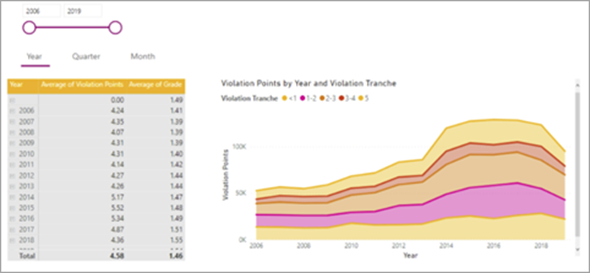
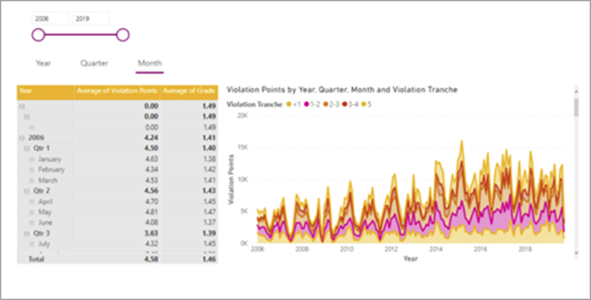



#### **Pop-up Overlays**
Use buttons and bookmarks to overlay an image, shape, or text box. A good example of a pop-up overlay is one that provides built-in assistance. In the following example, when the report consumer selects the Help button in the lower-left corner of the page, a full-page image becomes visible. The image includes many coach marks, which point to the targeted objects on the report page. Also, the image uses transparency so that the underlying report design remains partially visible. When the report consumer selects anywhere on the page, the image becomes hidden (due to an action on the image that uses a bookmark).
 
Two bookmarks are required for creating a pop-up overlay:
1. Configure the first bookmark to capture the Display state.
2. Ensure that the overlay object is visible, and then update the bookmark.
3. Assign the bookmark to a Help button action.
4. Configure the second bookmark to capture the Display state.
5. Ensure that the overlay object is hidden, and then update the bookmark.
6. Assign the bookmark to the overlay object.

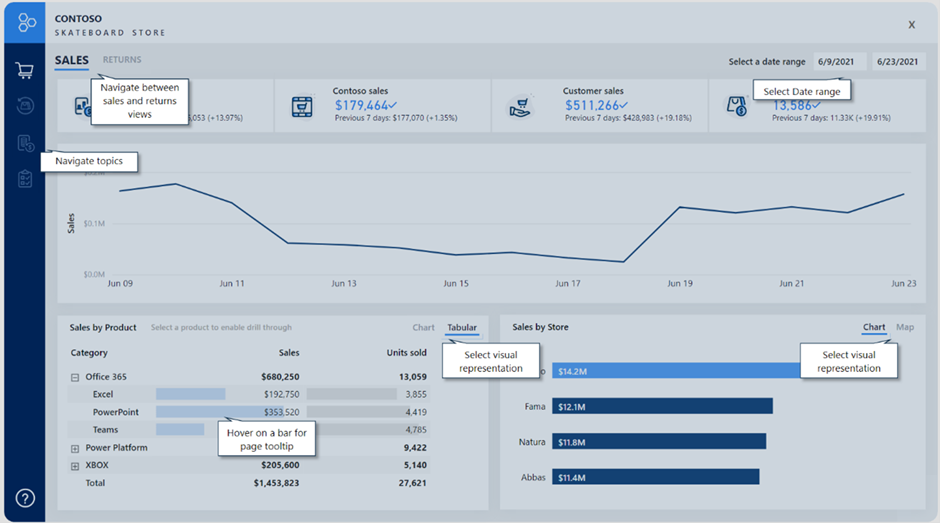



## **Analytics**

### **Statistical DAX Functions**

Power BI Desktop has a number of DAX functions that you can use to get quick statistics based on your data. You can access these quick functions by right-clicking the Values field in the Visualizations pane. However, to avoid performance issues, it's better to create the statistical measures yourself by using DAX functions to calculate average, sum, min, max, and so on. 


### **Top N Analysis**

The Top N analysis is a great way to present data that might be important, such as the top 10 selling products. You can accomplish this task in one of three ways: by using a Q&A visual, using a Top N filter, or writing a DAX formula. 



**Top N Filter Pane**

Top N is a filtering option that is available on the Filters pane.

**Top N DAX**

You can also calculate your top 10 products in DAX by using the `TOPN` function. This option could be useful if you want to present the top 10 in a different context, such as how much of the top 10 best-selling products contributed toward the overall total sales.

**Q&A Visual**

Power BI has a built-in Q&A visual that allows users to ask their own questions and get answers so you don't have to address each individual question. The Q&A visual is an effective tool because it allows users to quickly get answers about the data independently, which saves time for everyone involved.


### **Outliers**

The best visual to use for identifying outliers is the **scatter chart**, which shows the relationship between two numerical values. Scatter charts display patterns in large sets of data and are, therefore, ideal for displaying outliers. When you add a scatter chart to your Power BI report, you put your fields of interest in the X Axis and Y Axis sections, respectively. 

### **Grouping & Binning**

Grouping is used for categories of data. Binning is similar to grouping, but it is used for grouping continuous fields, such as numbers and dates. You can use the grouping and binning features to ensure that the visuals in your reports display your data according to your preference.

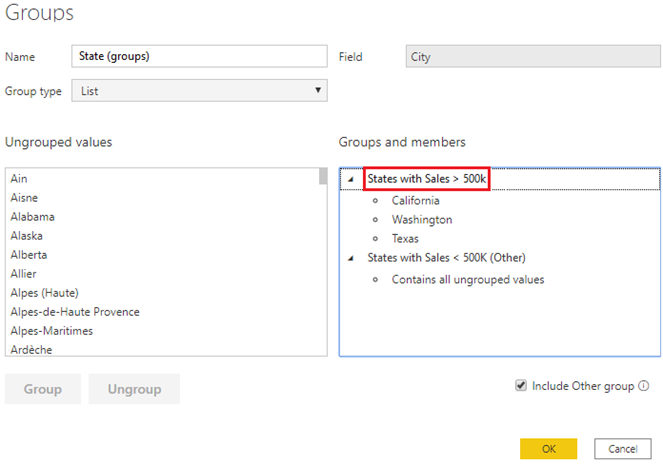

### **Histograms**

Histograms and bell curves are the most common way to display statistics about your semantic models. In Power BI terms, you can represent a histogram with one of the bar or column chart visuals and represent a bell curve with an area chart visual. 

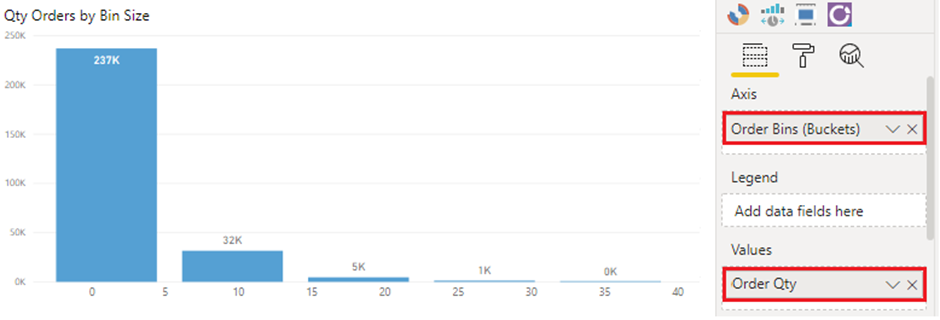

A typical bar or column chart visual in Power BI relates two data points: a measure and a dimension. A histogram differs slightly from a standard bar chart in that it only visualizes a single data point. To create the group, in the Fields pane, right-click the data field that you want to analyze and then select New Group. In the Groups window that displays, set up the bin group as follows:

1. Rename the group as Order Bins (Buckets).
2. Set the Group type option to Bin and the Bin Type option to Number of bins.
3. Enter 5 as the Bin count, 1 as the Min value, and 44 as the Max value.

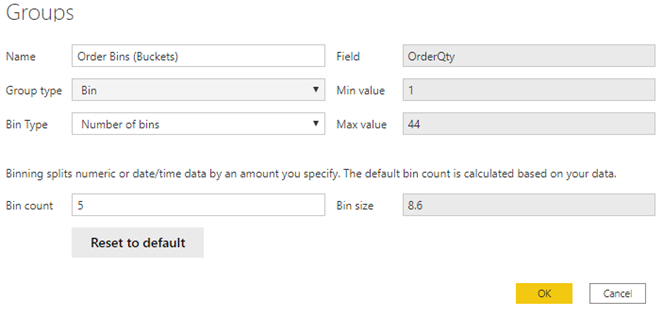


### **Clustering**

Clustering allows you to identify a segment (cluster) of data that is similar to each other but dissimilar to the rest of the data. The process of clustering is different to that of grouping, which you accomplished previously. The Power BI clustering feature allows you to quickly find groups of similar data points in a subset of your data. It analyses your semantic model to identify similarities and dissimilarities in the attribute values, and then it separates the data that has similarities into a subset of the data. These subsets of data are referred to as clusters.

To apply clustering to your scatter chart, select More options (...) in the upper-right corner of the visual and then select Automatically find clusters.

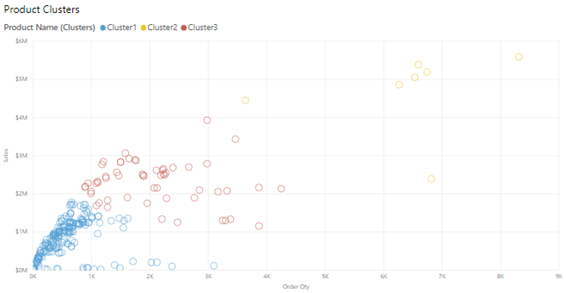


### **"Analyze Feature"**

The Analyze feature provides you with additional analysis that is generated by Power BI for a selected data point. You might want to use this feature to determine if Power BI has found something that you haven't seen before, or if you want Power BI to give you a different insight into your data. This feature is particularly useful for analyzing why your data distribution looks the way that it does. This feature does not work if you have non-numeric filters applied to your visual and/or if you have measure filters applied.

To use the Analyze feature, right-click a data point on the visual and then hover over the Analyze option to display two further options: "Explain the increase" and "Find where the distribution is different". The options that are available will depend on the data point that you selected.

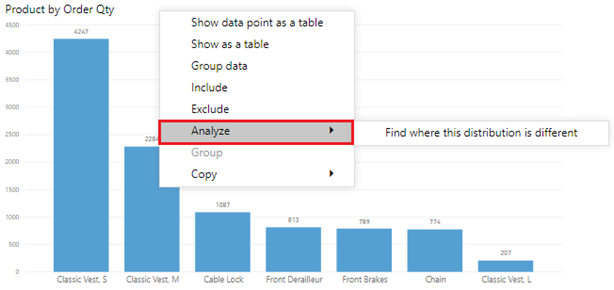


### **"What-if Parameters"**

You can use what-if parameters to run scenarios and scenario-type analysis on your data. What-if parameters are powerful additions to your Power BI semantic models and reports because they enable you to look at historical data to analyze potential outcomes if a different scenario had occurred. Additionally, what-if parameters can help you look forward, to predict or forecast what could happen in the future.

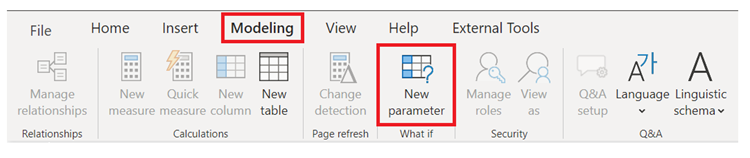

The new slicer visual will appear on the current report page. You can move the slider to see the numbers increase according to the settings that you applied. You should also see a new field for the Sales Forecast Percentage table in the Fields pane, and when you expand that field, the what-if parameter should be selected.

Similarly, you should see that a measure was also created. You can use this measure to visualize the current value of the what-if parameter. If you want to use the what-if parameter after you've created it, you will need to create a new measure whose value adjusts with the slider. You can create complex and unique measures that let your report users visualize the variable of your what-if parameter.


### **AI Visuals**

https://learn.microsoft.com/en-us/power-bi/create-reports/ 

Power BI includes several specialized visuals that provide a considerable interactive experience for report consumers. Often, these specialized visuals are called AI visuals because Power BI uses machine learning to discover and display insights from data. These visuals provide a simple way to deliver a rich and interactive experience to your report consumers.



#### **Key Influences**

The Key influencers visual helps report consumers understand the factors that drive a particular metric, like sales revenue. By using AI, Power BI will analyze the data, rank the factors that matter, and then present them as key influencers.

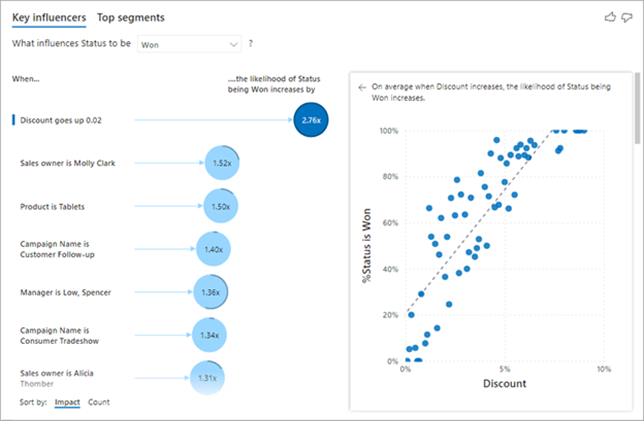

#### **Decomposition Tree**

The Decomposition Tree visual helps report consumers visualize data across multiple dimensions. It automatically aggregates data and enables consumers to drill down into dimensions in any order. As a result, it's a valuable tool for ad hoc exploration and conducting root cause analysis. As an AI visual, a decomposition tree provides a guided exploration experience that helps by finding the next dimension for consumers to drill down into.

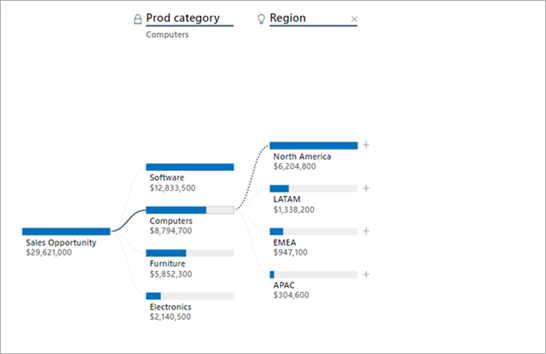

#### **Q&A Visual**

The Q&A visual allows report consumers to ask questions of their data and receive responses as data visualizations. Similar to how web search engines parse and understand complex search requests, report consumers can write natural language questions (in English).

Adding **synonyms** to model fields will help users search for them. For example, you can give a synonym of (Actuals) for the (Sales) measure. A **linguistic schema** describes terms and phrases that Q&A should understand for objects within a dataset, including parts of speech, synonyms, and phrasings that relate to that dataset. 

## **Reports**

### **Structure** 

Structurally, a Power BI report connects to a single semantic model (semantic model), and it has at least one report page. However, it's common that reports have multiple pages. On each page, report objects are laid out. Report objects include:
- **Visuals**: Visualizations of semantic model data.
- **Elements**: Provide visual interest but don't use semantic model data.Elements include text boxes, buttons, shapes, and images.

The decision to create more pages depends on your report requirements. Strive for a report design that expresses the data in a logical flow on the page and between pages. A well-designed report often provides a high-level summary on the first page with supporting detail on the following pages. You can provide report page navigation with buttons or by drilling through from a visual.

The **text box** deserves a special mention because it's capable of embedding dynamic values that are sourced from the report semantic model into paragraphs of text. When the page is filtered, dynamic values are filtered. Technically, the text box isn't a visual. However, in this instance, it behaves like one. It's also available as the smart narrative visual, which automatically summarizes data by using text descriptions and insights.

Dedicate an entire report page that includes instructions and definitions.


### **Design** 

Good report design layouts should consider design principles of placement, balance, contrast, proximity, and repetition. Always keep in mind that the less is more adage applies, simplicity and clarity lead to good design.

#### **Placement**

Good placement of report objects contributes to an ordered report design. Generally, you should place the most important information in the upper-left corner of the page and arrange the report elements from left to right and top to bottom. Arrange report objects so that the vertical and horizontal edges align because it looks ordered and is pleasing to the eye. Position-related report objects in logical groups. An ordered report layout creates a connection between visual elements and avoids clutter that can result from a seemingly random placement of report objects.

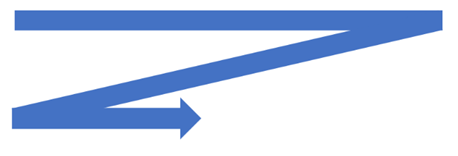

Additionally, aligning report objects in a visually pleasing layout can convey more energy and interest than simply centring or randomly placing report objects. Consider applying the rule of thirds, which is a visual arts rule that can be applied to report object placements in an analytical report. The rule proposes that a page layout should be divided into an invisible grid of nine equal parts. The grid is formed by two equally spaced horizontal lines and two equally spaced vertical lines. Then, report objects can be placed within the cells of the grid.

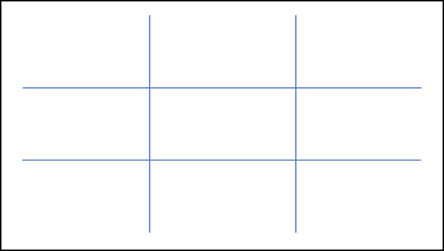


#### **Balance**
Another important consideration when you are laying out report objects is balance. Balance is concerned with stability and structure in design. In the context of a report layout, balance refers to the weight that is distributed across the report page by the placement of objects of the same or different sizes.

Balance can be symmetrical or asymmetrical. Symmetrical balance is achieved by distributing the weight evenly on both halves of the page. Asymmetrical balance is achieved through contrast. Consider using the golden ratio as a guide to produce asymmetrical balance.

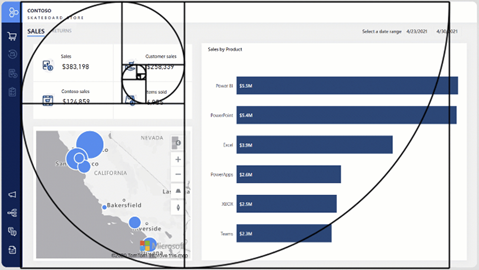



#### **Proximity**

In a report layout, proximity is concerned with the nearness of report objects. When a report page consists of multiple groups of related objects, you should use space to visually separate them.



#### **Contrast**
Contrast can be used to combine two opposing objects. The use of contrasting colors, fonts, font properties, or lines can emphasize important objects of the report design. Use this principle to direct report consumers to where they should look or which data visual they should interact with first.



#### **Repetition**

Repetition in a report design creates association and consistency. Good use of repetition can help strengthen a report layout by tying related report objects together.



#### **Margins**

Margins include the border area, or edge, around each page. Having a consistently spaced border area frames the report objects. Because there isn't a report page property to set margins, it's up to you to lay out objects in way that results in a consistent border area. Margin sizes should be equal on the left and right, with possible variation on the top and bottom. Space across the top or bottom can show branding, titles, slicers, or other information that needs to be separated from the visuals.



#### **Object Spacing**
Ensure that you provide sufficient space surrounding, or within, report objects. When visual headers are enabled, be sure to test that they don't overlap with nearby objects because overlapping objects can make interacting with visual header icons difficult. Appropriate spacing between visuals will help you avoid this problem.

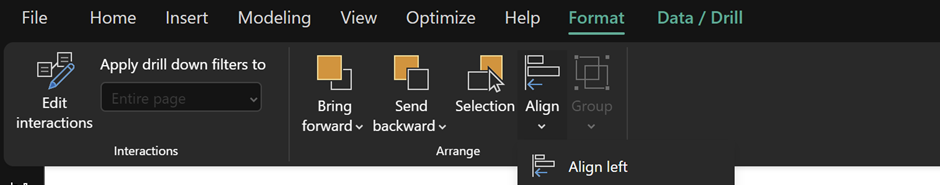


#### **Visual Size**
Generally, the more important the visual, the larger its size. Report consumers will quickly focus on larger visuals. When similar visuals are on the page, such as a series of card visuals, they should be equally sized.

While report consumers can use focus mode to enlarge a single visual, the visual should still clearly communicate its data when viewed at actual size on the report page. Focus mode can help consumers better interpret the data or more easily interact with the visual, such as expanding into levels of a matrix or decomposition tree visual.



#### **Alignment**

When multiple visuals are on the report page, ensure that they're properly aligned, meaning that the edges of visuals should be in alignment and the spacings between visuals are consistent. Alignment also relates to format options. For example, the alignment of titles and legends within visuals should be consistent.

Use the alignment commands on the Format tab, which will help you quickly and accurately align visuals.

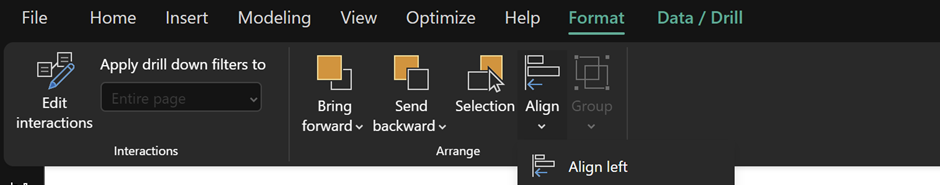


 
#### **Colour**

Use colour sparingly and meaningfully because overusing it can be distracting. Stick to a few softer colours as a base, possibly aligned with corporate colours. Softer colours ensure that the data is the focus in your report. Reserve the use of bolder colours to highlight exceptions. Ensure that colours are sufficiently contrasting.



#### **Consistency**
Strive for consistency when you are laying out and configuring report objects. Consistency should apply to everything in your report design, including spacing, margins, size, alignment, and especially to object format options. Format options include the selection of font, font size, font weight, colors, and many other styling options. Format options also include the enabling of visual features like axis labels and data labels.

The quickest way to enforce consistency is to use a report theme. A report theme applies format settings to your entire report, ensuring consistent application of colours, fonts, pages, and visual format options, including the Filters pane styles. Be sure to export the report theme, which is a JSON file, and then apply it to other reports to ensure consistency across all reports.


### **Report Types** 

Generally, report design can be classified by report type. Often, a direct mapping between the report audience and the report type occurs. Audience needs can be met by one, or possibly a combination, of four report types:
- Dashboard
- Analytical
- Operational
- Educational

Commonly, executives work with dashboards, analysts work with analytical reports, and information workers work with operational reports. Each report type has a different approach to the user interface (UI) and user experience (UX) requirements. The ability to combine data from multiple datasets is one of the features that is available in dashboards but not supported in reports.

#### **Dashboard**
The primary goal of a dashboard is to interpret the story as quickly as possible. User interactions are limited by insights that are highly curated toward the audience. Report visuals are focused, self-explanatory, and clearly labelled. A dashboard directly communicates the meaning behind the data to minimize misinterpretation or confusion.

A good example of a dashboard is an executive dashboard, which often presents high-level metrics that are displayed on a single page. Dashboards help answer questions such as "How are we doing?" or "Are we there yet?"


#### **Analytical Reports**
An analytical report is the most common type of report that can serve various report consumer use cases while providing a structured space for analysis. The primary goal of an analytical report is to help report consumers discover answers to a broad array of questions by interacting with the report and its visuals. Analytical reports often have many slicers to filter report data, and they often contain complex visuals that expose in-depth detail of the data.

Report pages are often expressly designed for interactivity with a focus on UX features. Multiple pathways are often provided for the report consumer to follow, which allows them to explore a topic of interest, share their findings, or return to where they started. Report consumers can remove layers and add context and detail by incorporating interactive features. Common interactive features include drill down, drill through, and tooltips.

A good example of an analytical report is one that extends beyond the "How are we doing?" type of question to answer the "Why did that happen?" or "What might happen next?" type of questions.



#### **Operational Reports**
Operational reports are designed to give the report consumer the ability to monitor current or real-time data, make decisions, and act on those decisions. Operational reports can include buttons that allow the report consumer to navigate within the report and also beyond the report to perform actions in external systems. Frequently, operational reports serve as a hub for action that is used by report consumers as part of their daily activity and workload.

This type of report should minimize the number of analytical features to ensure that focus remains on the operation that it's designed to serve. A streamlined user experience is the primary aim for this report type because excessive clicking or illogical flow can lead to high dissatisfaction.

A good example of an operational report is one that allows monitoring of a manufacturing production line. When an unexpected event arises, such as equipment malfunction, a button could allow workers to start a maintenance request.



#### **Educational Reports**

Educational reports assume that the report consumer is unfamiliar with the data or context. So, the reports must provide clear narrative detail and guidance to help with understanding. This type of report is often used in journalism and by governments to disseminate information to large audiences that have varying levels of understanding of the subject.

A good example of an educational report is one that describes the rollout of COVID-19 vaccination progress and that can be filtered by the home geographic region of the report consumer.


### **UI Requirements** 

User interface requirements relate to how reports are consumed and to the appearance and behaviour of reports. Aspects to consider include form factor, input method, style and theme, and accessibility.

**Form Factor**

In the context of report design, form factor describes the size of the hardware that is used to open reports, and to page orientation (portrait or landscape).

**Input Method**

When defining UI requirements, also consider input methods that are supported by devices or applications. While a computer has a keyboard and pointing device (mouse), mobile devices rely on common gestures, such as tap, double-tap, drag, pinch, spread, or press.

**Style and theme**

UI requirements should also consider style and theme. Strive to design reports with a consistent and distinctive appearance that is determined by a deliberate theme. The report theme should express your organizational branding or aim to complement it. At a minimum, the theme should include the following elements:
- A brand mark or logo symbol.
- A palette of colours that align to, or complement, organizational branding. The colours should also be sufficiently different so that, when applied to visuals, they provide appropriate contrast when appearing side by side.
- Text settings, including font selection, sizes, and colour.

To manage style and theme changes effectively and efficiently, design reports that use images and themes that are stored in a central repository. This approach improves change management: Changes that are applied to the repository can automatically cascade through to reports.

**Accessibility**

UI requirements should also factor in accessibility. Reports need to communicate to the broadest audience possible. So you should consider how report consumers with no-to-low vision or other physical disability can fully experience the reports. - Within the visual header options, you can enable the visual header tooltip. It adds the Help (?) icon to the visual header. Then, you can assign a page tooltip or text. This technique is beneficial for providing visual-specific guidance, such as more detail that describes definitions, calculation logic, or the source of data.


## **Performance Optimisation**

The performance optimization process involves minimizing the size of the semantic model and making the most efficient use of the data in the model, which includes:
- Ensuring that the correct data types are used.
- Deleting unnecessary columns and rows.
- Avoiding repeated values.
- Replacing numeric columns with measures.
- Reducing cardinalities.
- Analysing model metadata.
- Summarizing data where possible.

To optimize performance, you must first identify where the problem is coming from; in other words, find out which elements of your report and semantic model are causing the performance issues. Afterward, you can take action to resolve those issues and, therefore, improve performance.


### **"Performance Analyser"**

You can use Performance analyser in Power BI Desktop to help you find out how each of your report elements is performing when users interact with them. For example, you can determine how long it takes for a particular visual to refresh when it is initiated by a user interaction. When you identify the slowest query in the semantic model, you can focus on the biggest bottleneck first and establish a priority list to work through the other issues. Performance analyser highlights potential issues but does not tell you what needs to be done to improve them. 

Before you run Performance analyser, to ensure you get the most accurate results in your analysis (test), make sure that you start with a clear visual cache and a clear data engine cache.

- **Visual cache**: When you load a visual, you can't clear this visual cache without closing Power BI Desktop and opening it again. To avoid any caching in play, you need to start your analysis with a clean visual cache. To ensure that you have a clear visual cache, add a blank page to your Power BI Desktop (.pbix) file and then, with that page selected, save and close the file. Reopen the Power BI Desktop (.pbix) file that you want to analyse. It will open on the blank page.
- **Data engine cache**: When a query is run, the results are cached, so the results of your analysis will be misleading. You need to clear the data cache before rerunning the visual. To clear the data cache, you can either restart Power BI Desktop or connect DAX Studio to the semantic model and then call Clear Cache.
When you have cleared the caches and opened the Power BI Desktop file on the blank page, go to the View tab and select the Performance analyser option.

To begin the analysis process, select Start recording, select the page of the report that you want to analyse, and interact with the elements of the report that you want to measure. You will see the results of your interactions display in the Performance analyser pane as you work. When you are finished, select the Stop button.

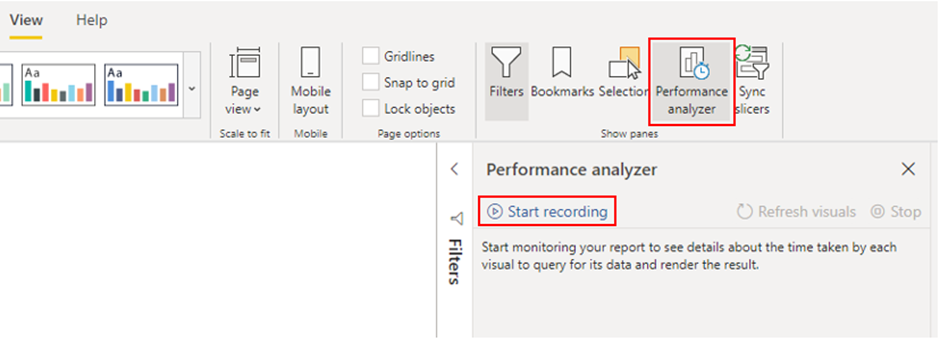

You can review the results of your performance test in the Performance analyzer pane. To review the tasks in order of duration, longest to shortest, right-click the Sort icon next to the Duration (ms) column header, and then select Total time in Descending order. The log information for each visual shows how much time it took (duration) to complete the following categories of tasks:
- **DAX query**: The time it took for the visual to send the query, along with the time it took Analysis Services to return the results. A good starting point is any DAX query that is taking longer than 120 milliseconds.
- **Visual display**: The time it took for the visual to render on the screen, including the time required to retrieve web images or geocoding.
- **Other**: The time it took the visual to prepare queries, wait for other visuals to complete, or perform other background processing tasks. If this category displays a long duration, the only real way to reduce this duration is to optimize DAX queries for other visuals, or reduce the number of visuals in the report.

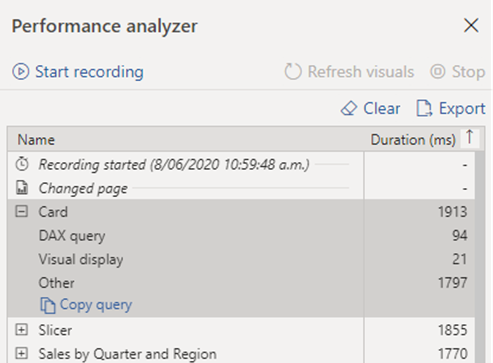


### **"Query Diagnostics"**

Another tool that you can use to study query performance is Query Diagnostics. You can determine what bottlenecks may exist while loading and transforming your data, refreshing your data in Power Query, running SQL statements in Query Editor, and so on.

To access query diagnostics in Power Query Editor, go to Tools in the Home ribbon. When you're ready to begin transforming your data or making other edits in Power Query Editor, select Start Diagnostics in the Session Diagnostics section. When you're finished, make sure that you select Stop Diagnostics.

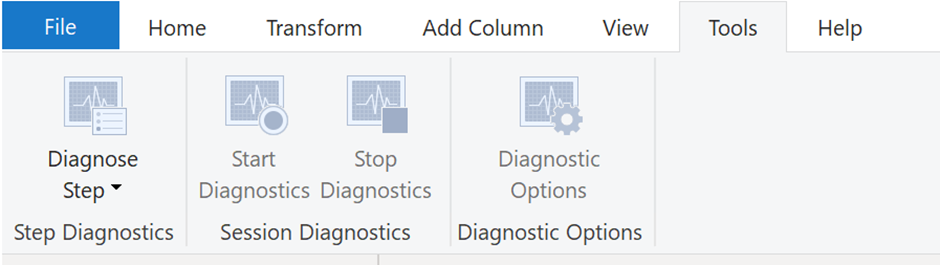

Selecting Diagnose Step shows you the length of time that it takes to run that step, as shown in the following image. This selection can tell you if a step takes longer to complete than others, which then serves as a starting point for further investigation.

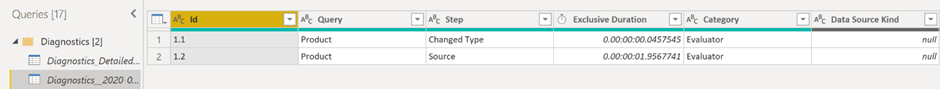

This tool is useful when you want to analyze performance on the Power Query side for tasks such as loading semantic models, running data refreshes, or running other transformative tasks.



### **Query Folding**
https://learn.microsoft.com/en-us/training/modules/get-data/8-performance-issues
https://learn.microsoft.com/en-us/power-query/query-folding-examples

Query Folding within Power Query Editor helps you increase the performance of your Power BI reports. Query folding is the process by which the transformations and edits that you make in Power Query Editor are simultaneously tracked as native queries, or simple `SELECT` SQL statements, while you're actively making transformations. Query folding is the ability for a Power Query query to generate a single query statement that retrieves and transforms source data.

The reason for implementing this process is to ensure that these transformations can take place in the original data source server and don't overwhelm Power BI computing resources. Queries that rely solely on unstructured data sources or that don't have a compute engine, such as CSV or Excel files (and even Parquet), don't have query folding capabilities. This means that Power Query evaluates all the required data transformations using the Power Query engine.

Native queries aren't possible for the following transformations:
- Adding an index column
- Merging and appending columns of different tables with two different sources
- Changing the data type of a column

A good guideline to remember is that if you can translate a transformation into a `SELECT` SQL statement, which includes operators and clauses such as `GROUP BY`, `ORDER BY`, `WHERE`, `UNION ALL`, and `JOIN`, you can use query folding. While query folding is one option to optimize performance when retrieving, importing, and preparing data, another option is query diagnostics.


### **Cardinality Reduction**

Previously, when you used Power Query Editor to analyse the metadata, the Column distribution option on the View tab displayed statistics on how many distinct and unique items were in each column in the data. Lower cardinality leads to more optimized performance, so you might need to reduce the number of high cardinally columns in your semantic model.
 
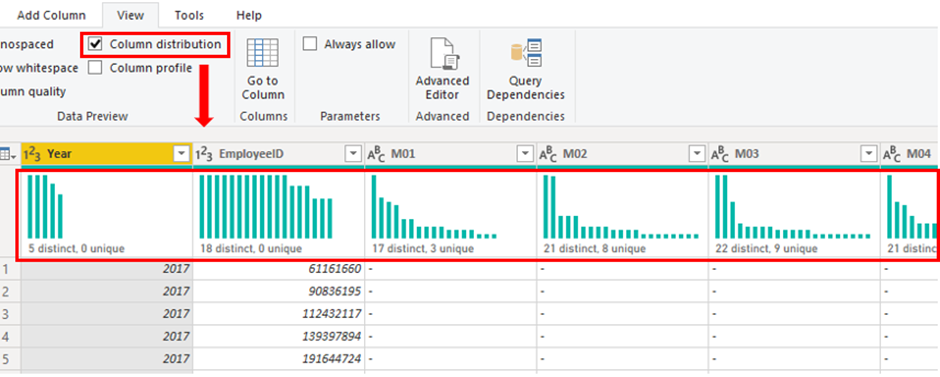

**Reducing cardinality levels through summarisation**

Reducing the data that is loaded into your model will improve the relationship cardinality of the report. Perhaps the most effective technique to reduce a model size is to use a summary table from the data source. You can create aggregations in different ways and each method will yield the same results, for example:
- If you have access to the database, you could create a table or view with the aggregation and then import that table or view into Power BI Desktop. 
- In Power BI Desktop, you can use Power Query Editor to create the aggregations step-by-step.

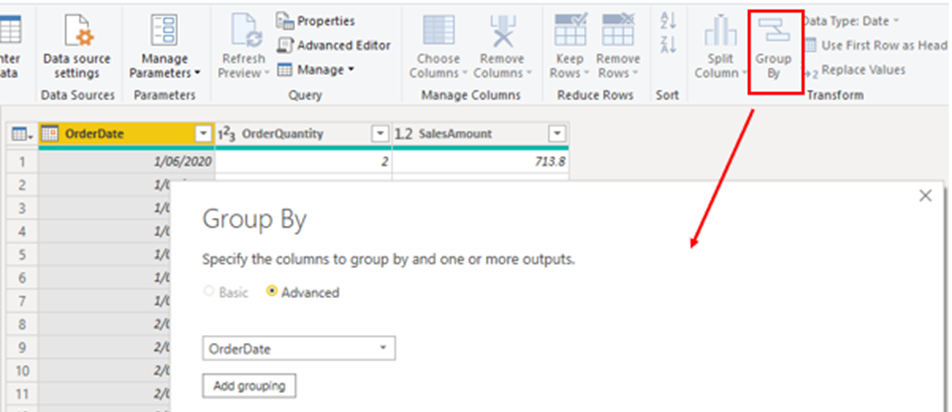
 
**Reduce relationship cardinality**

Your model will never work if you try to build a relationship between two columns, where one column has a text data type and another column has an integer data type. The columns with data type Integer perform better than columns with data type Text.





### **DAX Variables**
You can use variables in your DAX formulas to help you write less complex and more efficient calculations. When you declare at least one variable, a RETURN clause is used to define the expression, which then refers to the variables. We recommend that you use variables because they offer several benefits:
- Improving the readability and maintenance of your formulas.
- Improving performance because variables are evaluated once and only when or if they're needed.
- Allowing (at design time) straightforward testing of a complex formula by returning the variable of interest.

**Without variable**
```dax
Sales YoY Growth =
DIVIDE (
    ( [Sales] - CALCULATE ( [Sales], PARALLELPERIOD ( 'Date'[Date], -12, MONTH ) ) ),
    CALCULATE ( [Sales], PARALLELPERIOD ( 'Date'[Date], -12, MONTH ) )
)
```

**With variable**
```dax
Sales YoY Growth =
VAR SalesPriorYear =
    CALCULATE ( [Sales], PARALLELPERIOD ( 'Date'[Date], -12, MONTH ) )
VAR SalesVariance =
    DIVIDE ( ( [Sales] - SalesPriorYear ), SalesPriorYear )
RETURN
    SalesVariance
```

### **Visuals**

If you identify visuals as the bottleneck leading to poor performance, you should find a way to improve performance with minimal impact to user experience.
- Consider the number of visuals on the report page; fewer visuals mean better performance. 
- Examine the number of fields in each visual. The more visuals you have on the report, the higher chance for performance issues. 



### **Other Methods**
- Check that relationship cardinality properties are correctly configured. For example, a one-side column that contains unique values might be incorrectly configured as a many-side column.
- It is best practice to not import columns of data that you do not need. To avoid deleting columns in Power Query Editor, you should try to deal with them at the source when loading data into Power BI Desktop.
- The Auto date/time option allows you to work with time intelligence when filtering, grouping, and drilling down through calendar time periods. We recommend that you keep the Auto date/time option enabled only when you work with calendar time periods and when you have simplistic model requirements in relation to time.
- Process as much data as possible in the original data source. 
- Separate date and time, if bound together. If any of your tables have columns that combine date and time, make sure that you separate them into distinct columns before importing them into Power BI. This approach will increase compression abilities.


## **Model Security**

You can enforce model security by restricting access to subset of data, and by restricting access to specific model tables and columns. You might restrict access because some report consumers aren’t permitted to view specific data. Achieving this requirement commonly involves setting up **row-level security (RLS)**, which involves defining roles and rules in that filter data model. You can also set up **object-level security (OLS)**, to restrict access to entire tables or columns.

### **Perspective**

Tabular models can hide tables and columns (and other objects) by using a perspective. A perspective defines viewable subsets of model objects to help provide a specific focus for report authors. Perspectives are intended to reduce the complexity of a model, helping report authors find resources of interest. However, perspectives aren’t a security feature because they don’t secure objects. A user can still query a table or column even when it’s not visible to them.

Columns are hidden because they’re either used by relationships or will be used in row-level security configuration or calculation logic.


### **Dynamic Reports with Parameters**
https://learn.microsoft.com/en-us/training/modules/get-data/3b-parameters

Dynamic reports are reports in which the data can be changed by a developer according to user specifications. Dynamic reports are valuable because a single report can be used for multiple purposes. If you use dynamic reports, you'll have fewer individual reports to create, which will save organizational time and resources.

You can use parameters by determining the values that you want to see data for in the report, and the report updates accordingly by filtering the data for you. Creating dynamic reports allows you to give users more power over the data that is displayed in your reports; they can change the data source and filter the data by themselves.

### **Row-level security (RLS)**

https://learn.microsoft.com/en-us/fabric/security/service-admin-row-level-security 

As a data modeler, you set up RLS by creating one or more **roles**. A role has a unique name in the model, and it usually includes one or more **rules**. Rules enforce filters on model tables by using Data Analysis Expressions (DAX) filter expressions. 



#### **Rules**

Rule expressions are evaluated within row context. Row context means the expression is evaluated for each row using the column values of that row. When the expression returns TRUE, the user can “see” the row. You can define rules that are either static or dynamic.

**Static Rules**

Static rules use DAX expressions that refer to constants. 

**Dynamic Rules**

Dynamic rules use specific DAX functions that return environmental values (as opposed to constants). Environmental values are returned from three specific DAX functions:

- `USERNAME`(domain\username) or `USERPRINCIPALNAME`(user@domain.com): Returns the Power BI authenticated user as a text value. Be aware that the USERNAME function returns the user in the format of DOMAIN\username when used in Power BI Desktop. However, when used in the Power BI service, it returns the format of the user's User Principal Name (UPN), like username@adventureworks.com. Alternatively, you can use the `USERPRINCIPALNAME` function, which always returns the user in the user principal name format. 

```dax
Sales by Current User = 
CALCULATE(
    SUM(Sales[Sales Amount]),
    Sales[Salesperson] = USERNAME()
)
```

- `CUSTOMDATA`: Returns the CustomData property passed in the connection string. Non-Power BI reporting tools that connect to the dataset by using a connection string can set this property, like Microsoft Excel.

When possible, create rules that filter dimension tables instead of fact tables. It will help to deliver faster query performance.



#### **Roles**
To create RLS roles in Power BI Desktop, select the Modeling tab, and then select Manage Roles. On the Manage roles page, select Create.

##### **Creating Roles**

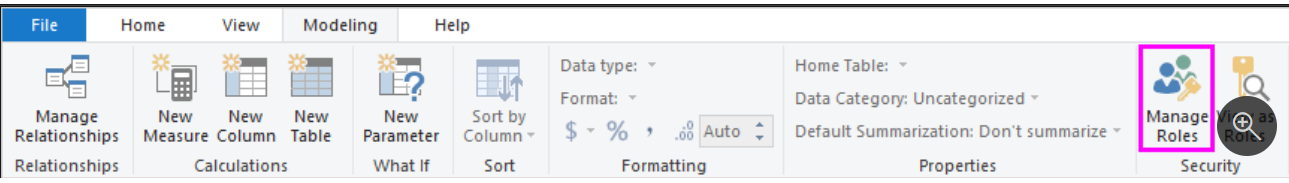

**Static Rules**

On the Manage roles page, create a role for each department and then add a DAX expression to it. For instance, you can create a role called Game and then add the DAX expression [department] = "Game". Then, whenever a member of that role interacts with the report, Power BI will add that filter to their interactions, thus limiting what they see.

A fixed value is used in the filter on the right side of the equal sign (in this case, "Game"). The intention is that, if you ever need to add a category, you will need to create a new role with a new value in the DAX expression.

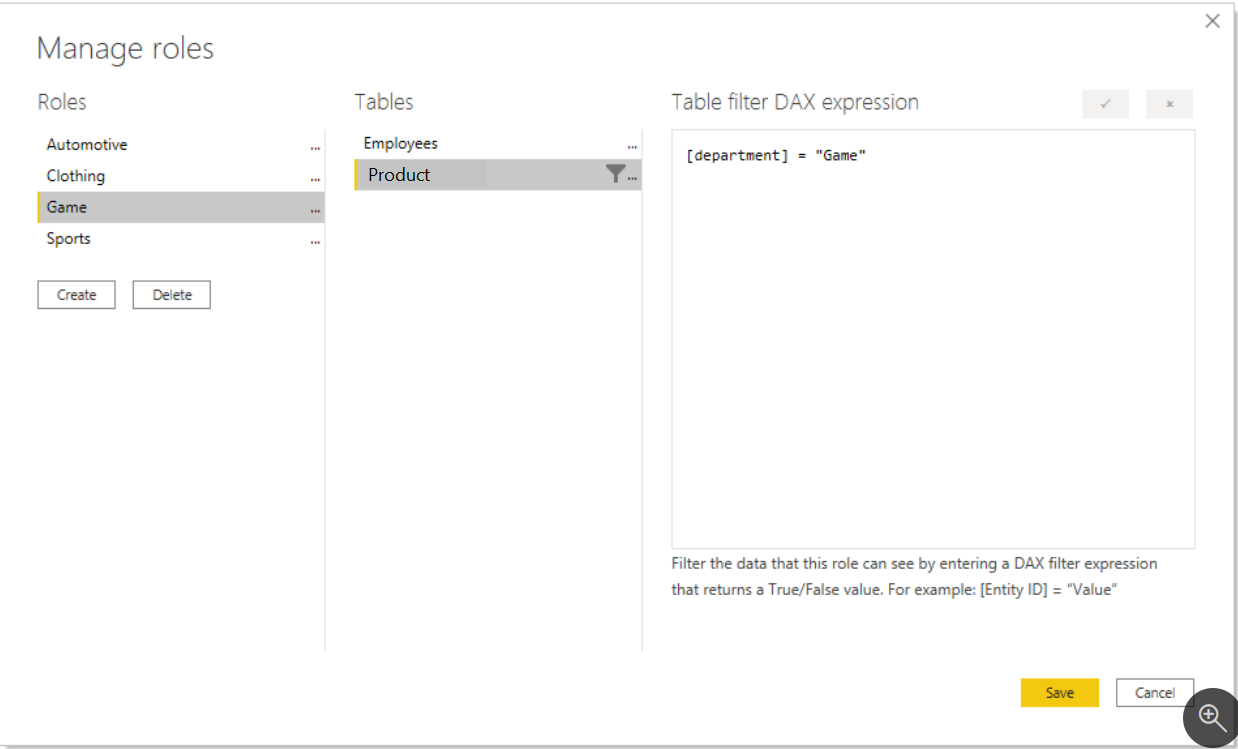

**Dynamic Rules**

You can set up row-level security only once, without the need to continue maintaining it dynamically.

As the admin at Tailwind Traders, you want Power BI row-level security to only show sales to the person who made them. In this example, Russel King has made four sales. When viewing your report, Russel should only see the sales that he's responsible for and no other sales. You can configure row-level security exactly the way you configured it previously, with only a single change. Instead of creating four roles, you only need to create one role. The DAX filter for that role would look similar to the following image.

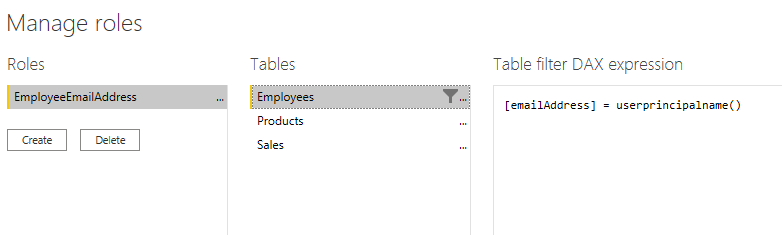

Notice that instead of the fixed string, such as Game or Clothing, this uses a DAX function in the row-level security filter. The `USERPRINCIPALNAME()` function will compare the email address from the Employees table with the email that the user entered when signing in to Power BI service. If Russel King uses the email address russel@tailwindtraders.com to sign in to Power BI service, the system will compare that value to the email address in the Employees table. Assuming that a relationship has been created between Employees and Sales, Russel will only see his four sales.


##### **Viewing Roles**

When you create roles, it’s important to test them to ensure they apply the correct filters. For data models created in Power BI Desktop, there’s the View as function that allows you to see the report when different roles are enforced, and different username values are passed.

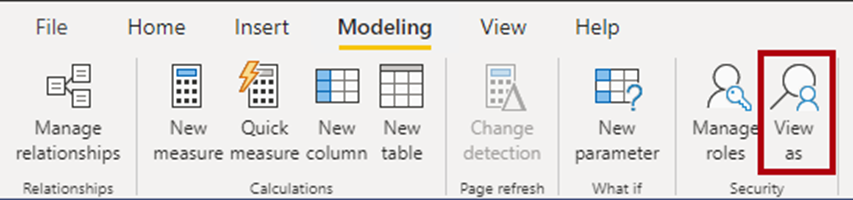
 
Strive to define fewer datasets (data models) with well-designed roles. Strive to create fewer roles by using dynamic rules. A data-driven solution is easier to maintain because you don’t need to add new roles.

You can deploy the report to Power BI service by selecting the Publish button on the Home tab and then selecting a workspace. To add members to the role in Power BI service, go to your workspace in Power BI service. Find the semantic model that you created with the same name as your report. Select the ellipsis (...) button and then select Security.

In the Row-Level Security screen, you can add Microsoft Entra ID users and security groups to the security role. When members are added to this role, the DAX filter that you previously defined will be applied to them. If members are not added to the role, but they have access to the report, RLS will not apply to them. You can add the three people in the Game department to the Game role. Now, when those members sign in, they will only see the report with data that applies to them.

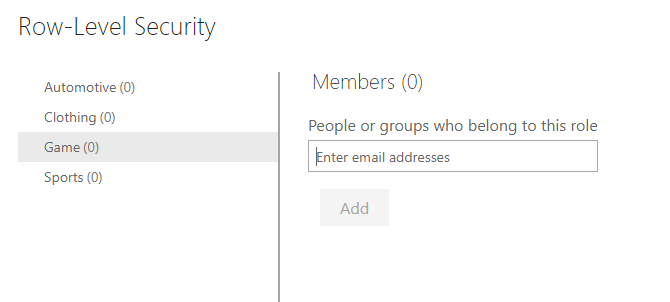

You can test the roles inside Power BI service by selecting the ellipsis (...) next to the Game role on the Row-Level Security screen and then selecting Test as role.

### **Object-level security (OLS)**

https://learn.microsoft.com/en-us/fabric/security/service-admin-object-level-security?tabs=table 

Object-level security (OLS) can restrict access to specific tables and columns, and their metadata. Typically, you apply OLS to secure objects that store sensitive data, like employee personal data.

To set up OLS, you start by creating roles. You can create roles in Power BI Desktop in the same way you do when setting up RLS. Next, you need to add OLS rules to the roles. This capability isn’t supported by Power BI Desktop, so you’ll need to take a different approach.

There are restrictions to be aware of when implementing OLS. You can’t mix RLS and OLS in the same role. If you need to apply RLS and OLS in the same model, create separate roles dedicated to each type. Also, you can’t set table-level security if it breaks a relationship chain. For example, if there are relationships between tables A and B, and B and C, you can't secure table B. If table B is secured, a query on table A can't transit the relationships between table A and B, and B and C. In this case, you could set up a separate relationship between tables A and C. 


## **Dashboards**

However, if you didn't have established permissions, you would be denied access to see the data. This verification ensures that only appropriate users have access to view the data, which helps make sure that your data is secured. The Power BI dashboard is similar to a dashboard in a car - you want to have the most important information for the consumer to see immediately. For additional insights, consumers can follow through to the corresponding report. Dashboards are often the next step after building your reports in Power BI Desktop.

|Dashboards|Reports|
|-|-|
|Create in service|Create in Power BI Desktop|
|Single pages|Multiple pages|
|Static tiles|Interactive visuals|
|Read-only tiles|Filters pane|

Dashboards are created by pinning report visuals, and are then called tiles within reports. When you make changes to the visuals in the report, and then republish to Power BI Service, changes are reflected on the dashboard.

One of biggest benefits of a dashboard is being able to pin a visual that is sourced from a different semantic model. In the following image, we show two separate tiles pinned from different reports.

### **Data Alerts**

Configuring data alerts is a simple process to complete for a dashboard in Power BI. Data alerts can notify you or a user that a specific data point is above, below, or at a specific threshold that you can set. These alerts are features that are only available on Power BI service and they're available on such report elements such as KPI visuals, gauges, and cards.

Finally, select how frequently you want alerts. These alerts are sent directly to your Notification Center in Power BI, and you can also configure emails.

This feature is available to all consumers to configure as they so choose. You can also enable or disable the alert by using the toggle switch.

### **Q&A Feature**

Power BI dashboards are about having a user-friendly experience. When users first interact with data, they often have additional questions and reach out to you. A few questions might be manageable to answer, but this isn't sustainable.

Power BI solves this problem with the Q&A visual. From the dashboard view, users can use the Ask a question about your data feature, which increases engagement between users and the dashboard.

### **Quick Insights Feature**

The Quick insights feature in Power BI uses machine learning algorithms to go over your entire semantic model and produce insights (results) for you quickly. This feature is a great way to build dashboards when you don't know where to start. It also helps you find insights you might have missed when building your reports. From the insights that Power BI discovers, you can generate appealing, interactive visualizations.

This feature is available in the Power BI service only. Also, this feature doesn't work with DirectQuery; it only works with data that is imported to Power BI. The Quick Insights page contains up to 32 separate insight cards, and each card has a chart or graph plus a short description.

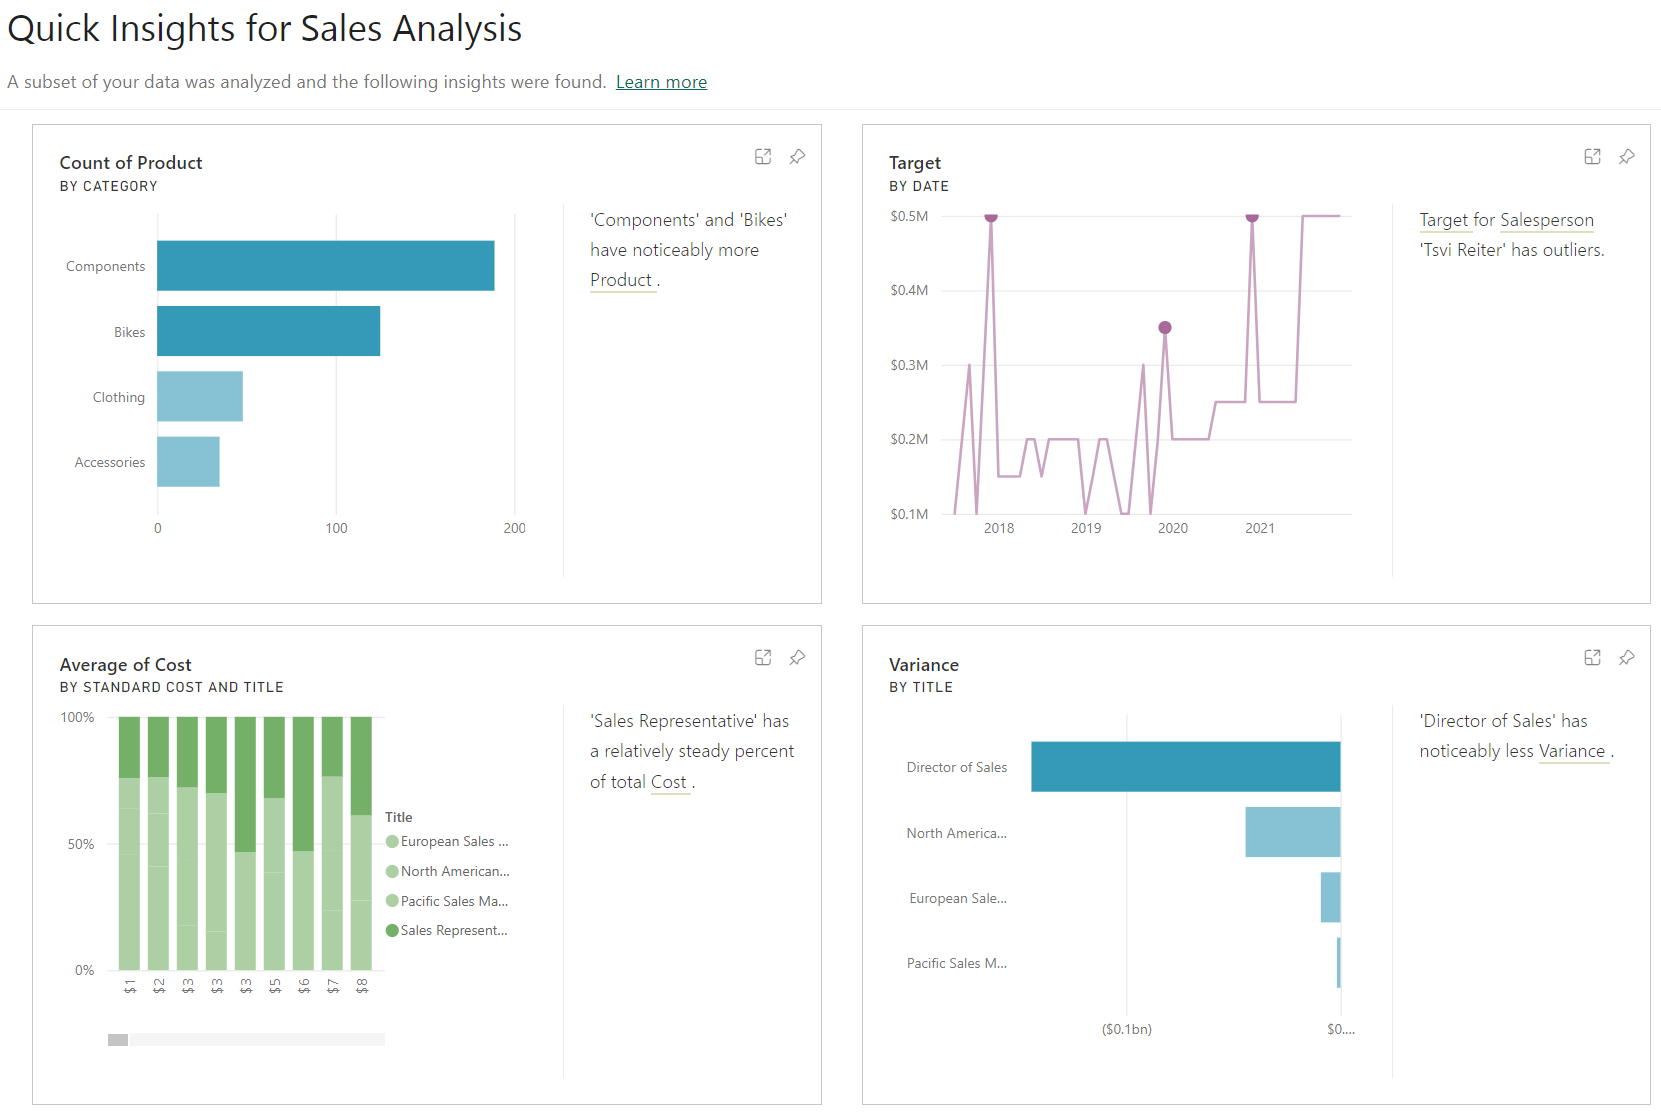

If you see a compelling insight card, you can even pin it to your dashboard. You can then perform the following actions:
- Filter the visualization by using the available options in the Filters panel.
- Run insights on the card (scoped insights) by selecting Get insights in the upper-right corner.

### **Theme**

When building dashboards, you can create a cohesive picture by applying the same theme as in your reports. Or apply a specific theme to reports and dashboards so that all report elements or tiles are uniform.

This consideration is important when you're building multiple dashboards. Power BI provides options to apply a theme directly to a dashboard as well as all visuals of a report.

You can also upload your own JSON theme or download the current theme.

### **Live Page**

Power BI allows you to pin live report pages to dashboards, ensuring that your visuals reflect real-time changes. The iterative process of building reports and dashboards as business requirements evolve becomes easier with this feature. These visuals are live, meaning that any changes you make on the report are immediately reflected on the selected dashboard.

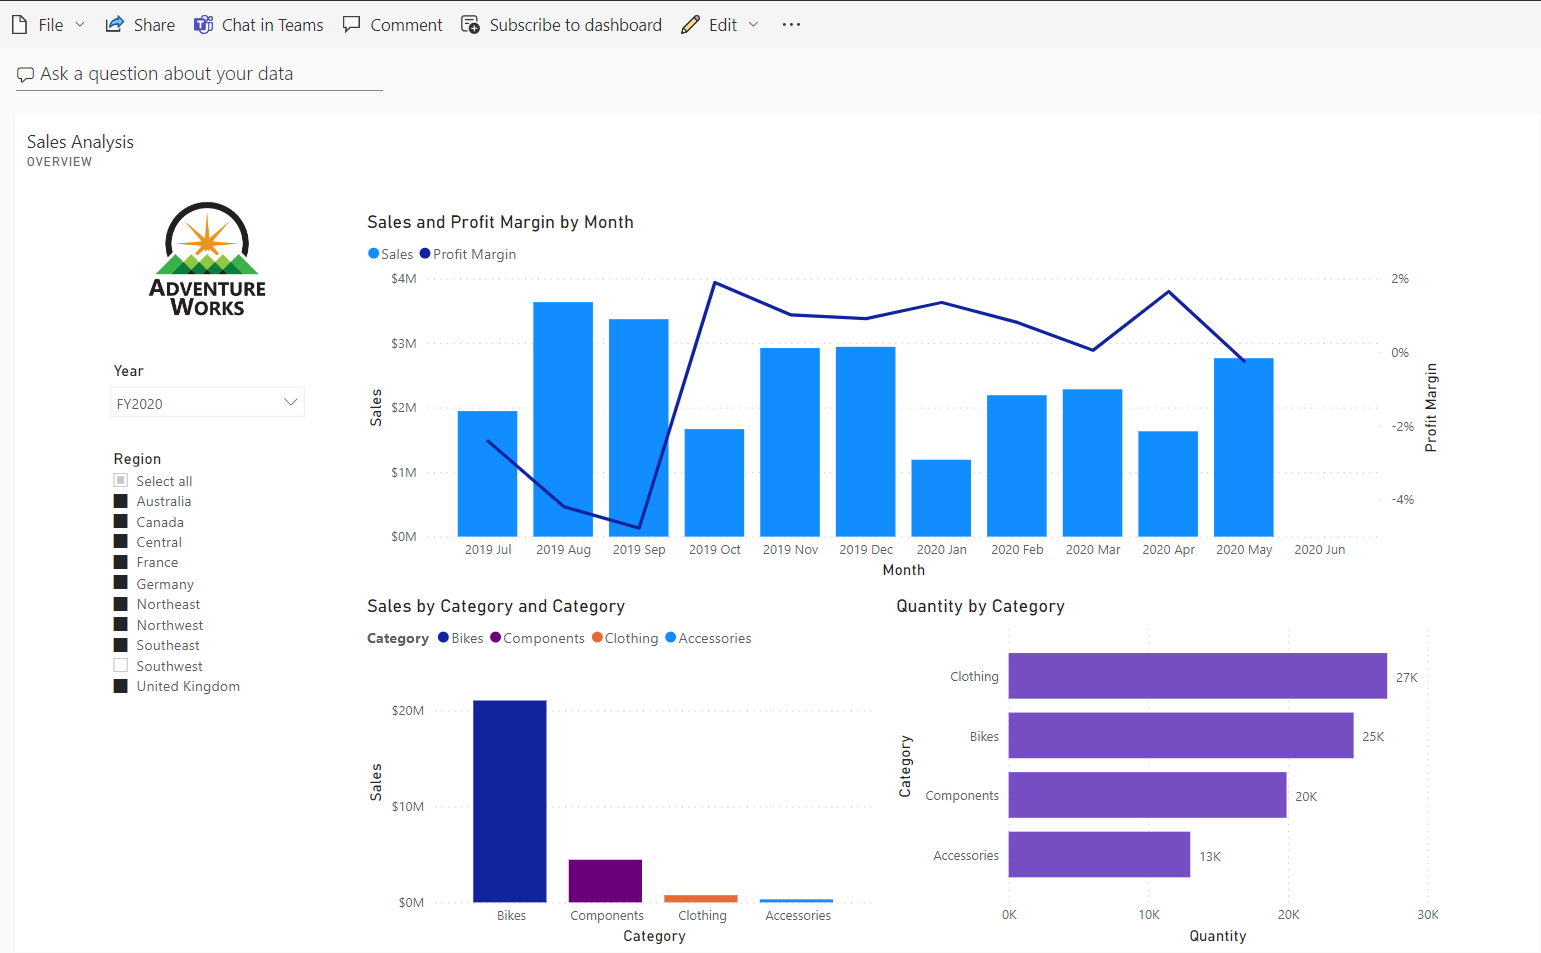

Dashboards are intended to be a collection from various sources, not just as a "launching pad" for reports. We recommend that you pin at the tile level first and foremost, and if needed, the entire report page can also be pinned. Seeing an entire report page in a dashboard tile can be difficult.

### **Streaming Tiles**

Streaming data can come from various sources, including from social media, factory sensors, service-usage metrics, and other sources that contain a constant stream of data points.

Data that comes from a streaming data source is stored in a temporary cache, not a semantic model. This means you can't make changes to the semantic model. The only way to visualize the data from a streaming data source is to create a tile directly on a dashboard and use a custom streaming data source. These tiles are optimized because no database exists to pull the data from. These types of tiles have low latency and are best suited for data that doesn't need additional transformations, such as temperature or humidity.

Streaming semantic model tiles can be formatted as line charts, stacked bar charts, cards, and gauges, similarly to any other tiles.

### **Mobile View**

Power BI reports are built in Power BI Desktop and then deployed to Power BI service, where they can be viewed and shared. However, if you're building dashboards for your organization and need reports and dashboards viewable on mobile devices, Power BI offers a mobile layout configuration to meet your needs.

In the mobile view in Power BI Desktop, you're able to accomplish several tasks. The mobile view shows you how it will look to users in the Power BI Mobile app. You can add visuals, resize them, and change the formatting. Use the grid view to orient your visuals with more ease and overlay visuals on top of each other. This feature can be useful if you want to insert a visual on top of an image.

## **Workspaces**

You've likely had the chance to load and transform data from numerous sources, build visuals, create DAX equations, and even publish a report or two to Microsoft Power BI. The next step on your data analysis journey is to share these reports with your wider audiences and organizations. You can accomplish this task in a workspace, which is a feature of Power BI. A workspace is a centralized repository in which you can collaborate with colleagues and teams to create collections of reports and dashboards.

### **Roles**

Workspace roles allow you to designate who can do what within a workspace. There are four roles for workspaces, and it's advised that you grant the minimum access necessary to collaborators. For consumers, skip workspace role assignment, and provide access through the app instead in the next section.

**Admin**

- Update and delete the workspace
- Add or remove people, including other admins

**Member**

- Add members or others with lower permissions
- Publish, unpublish, and change permissions for an app

**Contributor**

- Create, edit, and delete content, such as reports, in the workspace
- Publish reports to the workspace

**Viewer**

- View and interact with an item
- Read data that's stored in workspace dataflows


### **Semantic Models**

When your semantic models are published to your organization's workspace in Microsoft Power BI service, everyone who needs access to those semantic models can find them in a central location, which provides opportunities for collaboration between teams. The sharing of semantic models needs to be actively managed for optimal organizational performance. 


#### **Gateway**

Gateway software acts like a bridge; it allows organizations to retain databases and other data sources on their on-premises networks and access that on-premises data in cloud services, such as Power BI and Microsoft Azure Analysis Services.

A gateway facilitates quick, behind-the-scenes communication that flows from a user in the cloud to your on-premises data source and then back again to the cloud.

Two types of on-premises gateways are:
1. **Organization mode**: Allows multiple users to connect to multiple on-premises data sources and is suitable for complex scenarios.
2. **Personal mode**: Allows one user to connect to data sources. This type of gateway can be used only with Power BI and it can't be shared with other users, so it is suitable in situations where you're the only one in your organization who creates reports. You will install the gateway on your local computer, which needs to stay online for the gateway to work.

Cloud services, such as SharePoint, do not require a gateway because the data is already in the cloud. You only need to provide your authorization credentials to set up a data source connection. The Workspace OneDrive setting allows you to configure a Microsoft 365 group whose SharePoint Online document library is available to workspace users once the workspace is created.

#### **Scheduled Refresh Feature**

The Scheduled refresh feature in Power BI allows you to define the frequency and time slots to refresh a particular dataset. Scheduling the refresh of your data will save you time because you don't have to manually refresh the data. It also ensures that users can access the most up-to-date data.

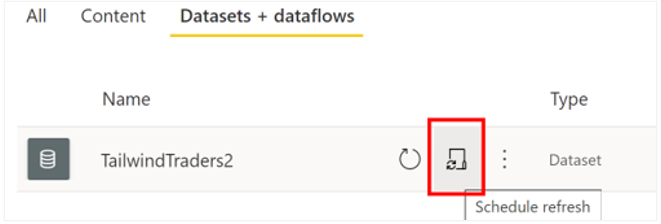

While you can set a time for the refresh, be aware that the refresh might not take place at that exact time. Power BI starts scheduled refreshes on a best effort basis. The goal is to initiate the refresh within 15 minutes of the scheduled time slot, but a delay of up to one hour can occur if the service can't allocate the required resources sooner. In a Premium per user workspace the limit is 48 refreshes per day for a dataset.

In this example, you want the system to refresh the sales data on a daily basis, at 6:00 AM, 10:00 AM, and 3:00 PM, as illustrated in the following image.

#### **On-demand Refresh**

In addition to the scheduled refreshes, you can refresh a dataset at any time by performing an on-demand refresh. This type of refresh doesn't affect the next scheduled refresh time.

For example, you might want to refresh now because you need to view the most recent data and can't wait for the next refresh time, or you might want to test your gateway and data source configuration.

#### **Refresh Status & History**

You can check the refresh status and history at any time. This feature is useful if you want to find out when the last refresh occurred and when the next one is scheduled. It is also good practice to check the status of your semantic models occasionally to check if refresh errors have occurred.

Power BI deactivates your refresh schedule after four consecutive failures or when the service detects an unrecoverable error that requires a configuration update, such as invalid or expired credentials. It is not possible to change the consecutive failures threshold.

If a semantic model displays a small warning icon, you'll know that the semantic model is currently experiencing an issue. Select the warning icon to get more information.

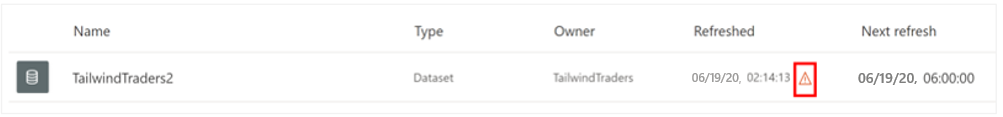

You should also check the refresh history occasionally to review the success or failure status of past synchronization cycles.

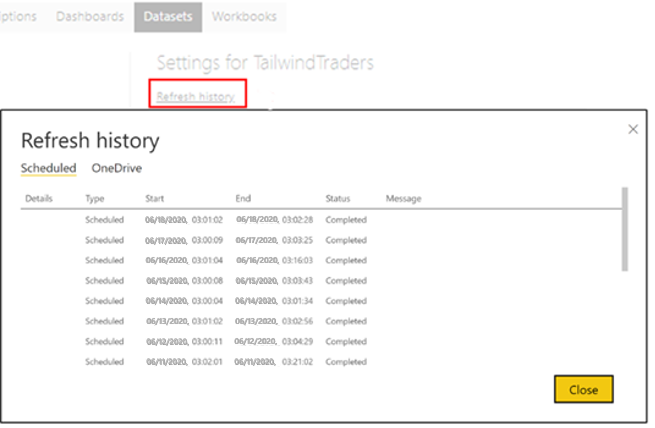

#### **Incremental Refresh Feature**

The Incremental refresh feature in Power BI is a popular feature because it allows you to refresh large semantic models quickly and as often as you need, without having to reload historical data each time.

Incremental refresh should only be used on data sources and queries that support query folding. If query folding isn't supported, incremental refresh could lead to a bad user experience because, while it will still issue the queries for the relevant partitions, it will pull all data, potentially multiple times.

Traditionally, complex code was required for running incremental refreshes, but you can now define a refresh policy within Power BI Desktop. The refresh policy is applied when you publish to Power BI service, which then does the work of managing partitions for optimized data loads, resulting in the following benefits:
- Quicker refreshes - Only data that needs to be changed gets refreshed. For example, if you have five years' worth of data, and you only need to refresh the last 10 days because that is the only data that has changed, the incremental refresh will refresh only those 10 days of data. Undoubtedly, the time it takes to refresh 10 days of data is much shorter than five years of data.
- More reliable refreshes - You no longer need to keep your long-running data connections open to schedule a refresh.
- Reduced resource consumption - Because you only need to refresh the smaller the amount of data, the overall consumption of memory and other resources is reduced.

You can define an incremental refresh policy to solve this business problem. This process involves the following steps:
1. Define the filter parameters.

    For incremental refresh, the semantic models are filtered by two date/time parameters: `RangeStart` and `RangeEnd`. These parameters have a dual purpose. In Power BI Desktop, they are the filtering window because they restrict the used data to the range that is listed in the start and end dates. After they have been published to the service, the parameters are taken over to be the sliding window to determine what data to pull in.

    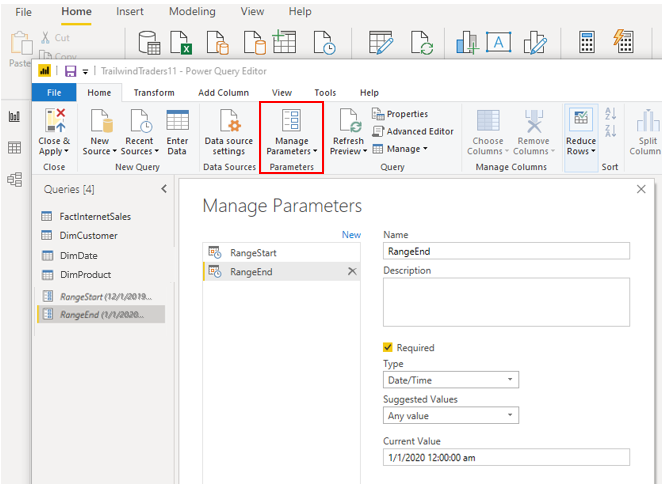
    
2. Use the parameters to apply a filter.
3. Define the incremental refresh policy.
4. Publish changes to Power BI service.

#### **Endorsement**

Power BI provides two ways to endorse your semantic models:
1. **Promotion**: Promote your semantic models when they're ready for broad usage.
2. **Certification**: Request certification for a promoted semantic model. Certification can be a highly selective process, so only the truly reliable and authoritative semantic models are used across the organization.

##### **Promotion**
To promote content, you must have write permissions on the workspace where the content you want to promote is located. When you return to your workspace, a badge in the Endorsement column for that semantic model will appear, indicating that it's ready for viewing by all of your users.

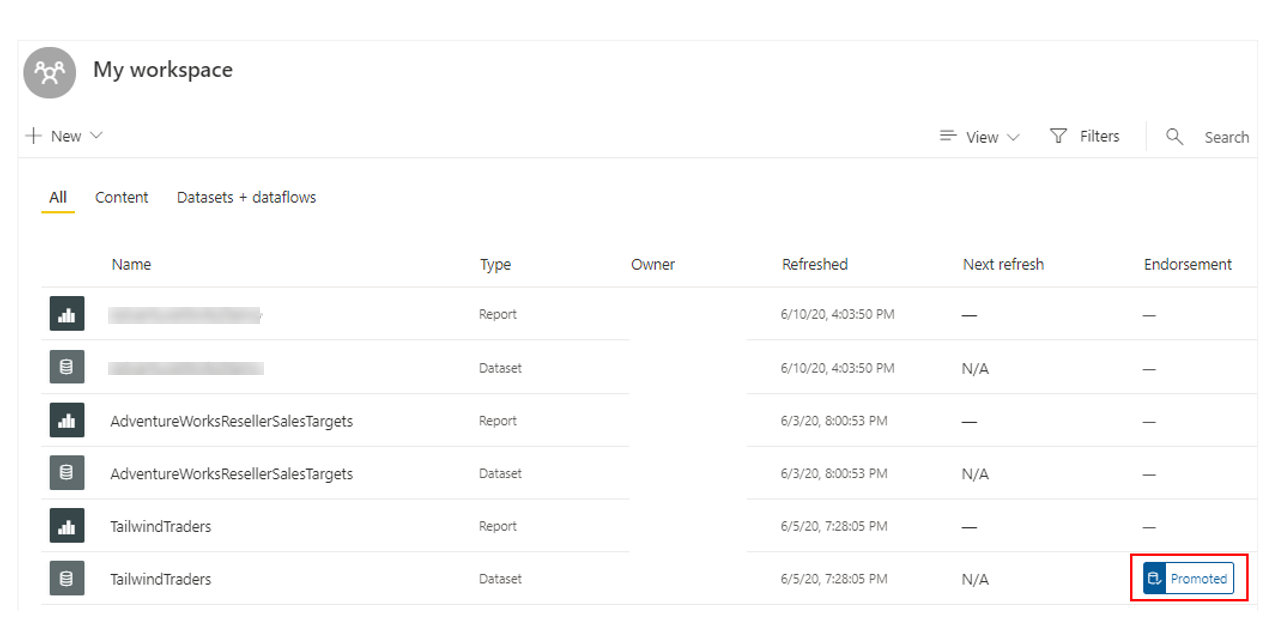

##### **Certification**
Content certification is a big responsibility, and only authorized users can certify content. Other users can request content certification.

#### **"Query Caching Feature"**

Query Caching is a local caching feature that maintains results on a user and report basis. Query caching reduces load time and increases query speed, especially for semantic models that aren't refreshed often and are accessed frequently. This service is only available to users with Power BI Premium or Power BI Embedded.

Query caching results are user-specific, and apply specific page of a report only. With the Query Caching feature, you can use the local caching services of Power BI to process query results. Instead of relying on the semantic model to calculate queries, you use cloud resources on your Premium capacities in the Power BI service to load your report. Query caching ensures constant performance instead of overloading the semantic model resources.

### **Apps**

After creating an app workspace and assigning your collaborator-specific roles, you want to add content to your app workspace. Content can be in the form of reports, dashboards, semantic models, dataflows, and so on.

An app is a published, read-only window into your data for mass distribution and viewing. When ready to share apps with your users, you can publish the app. This process requires a Power BI Pro license. Consuming and viewing an app also requires a Pro license, or the workspace must be hosted in a Premium capacity.

When you are ready to publish your app with its collection of reports, dashboards, and semantic models, return to the workspace and select Create app in the upper-right corner of the ribbon. The Build your app experience starts on the Setup page, where you add a name and description for the app. You can also customize the theme color and add a logo if desired.

Under the Content tab, you can choose which content to include and change the viewing order. You can add content in the workspace, new sections for grouping, and external links.

In the Audience tab, you're now able to choose one or more audiences with different viewing options. First, you'll select which reports you want visible to the default audience created. Select what content each audience sees by toggling the eye icon on the right. In the following screenshot, the audience is called "Sales" by default, but you can right-click and rename it.

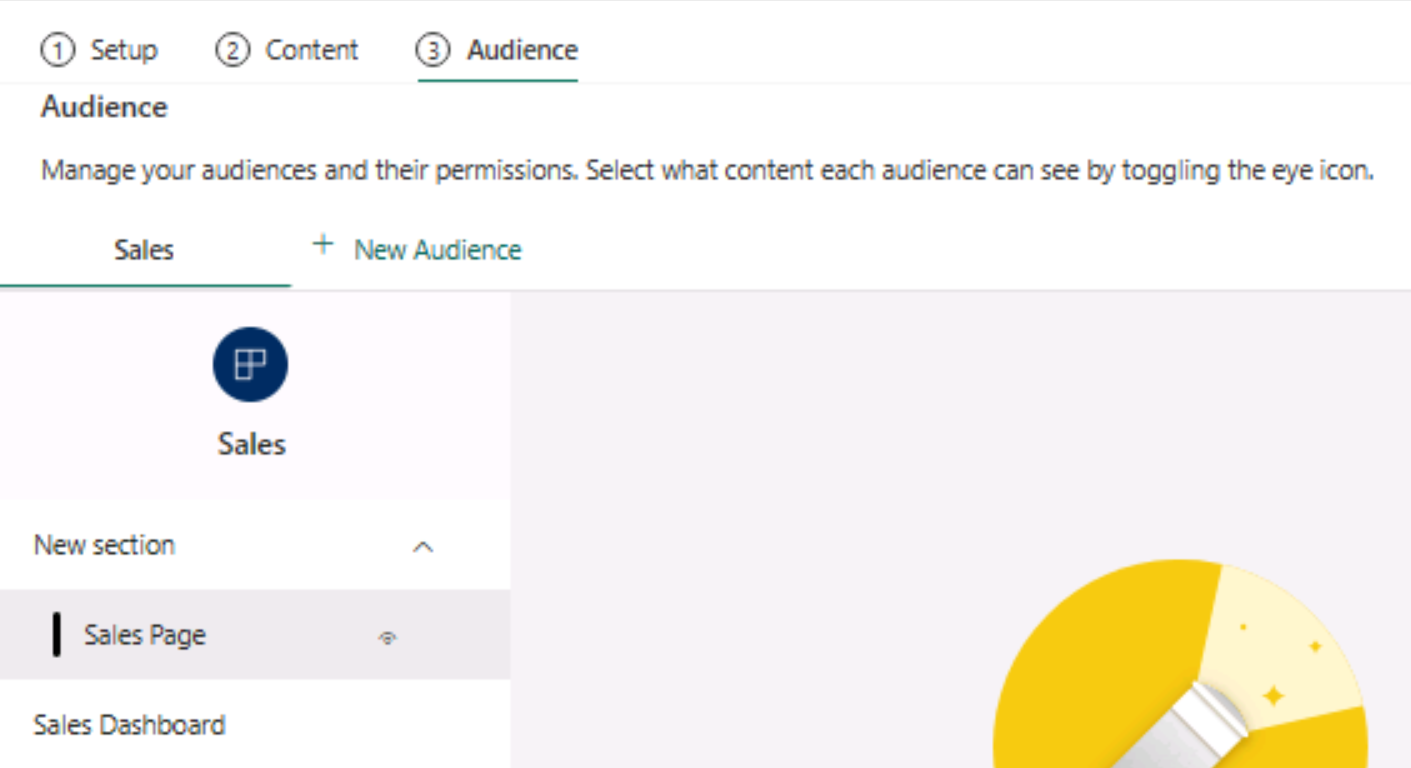

After selecting the viewable content, you can Manage Audience Access. You can Grant access to the Entire organization or Specific users or groups. For Specific users or groups, you can enter any mail-enabled account accessible within your Power BI tenant. Lastly, notice that Workspace users are already included in the audience by default. This goes back to the roles we covered earlier.

When you're ready, select Publish app. Congratulations, you just published an app! You'll receive a notification with the link to distribute to consumers, and an option to go to the app. Workspace apps can be installed automatically for any user in an organization, and without requiring notifications of installation. 


### **Usage Monitoring**

These performance and usage metrics are available features that you can use in a workspace. With these metrics, you can view who's using your reports, what actions are being done on the reports, and what performance issues exist.

Usage metric reports are available for Power BI Pro users and can only be accessed by users with the role types of Admin, Member, or Contributor.

To view usage metric reports, go to the pertinent workspace. Find the report or dashboard that you want to see usage metrics for. For example, if you want to see the usage metrics report for Sales Data, select the ellipsis (...), and then select View usage metrics report from the drop-down menu.

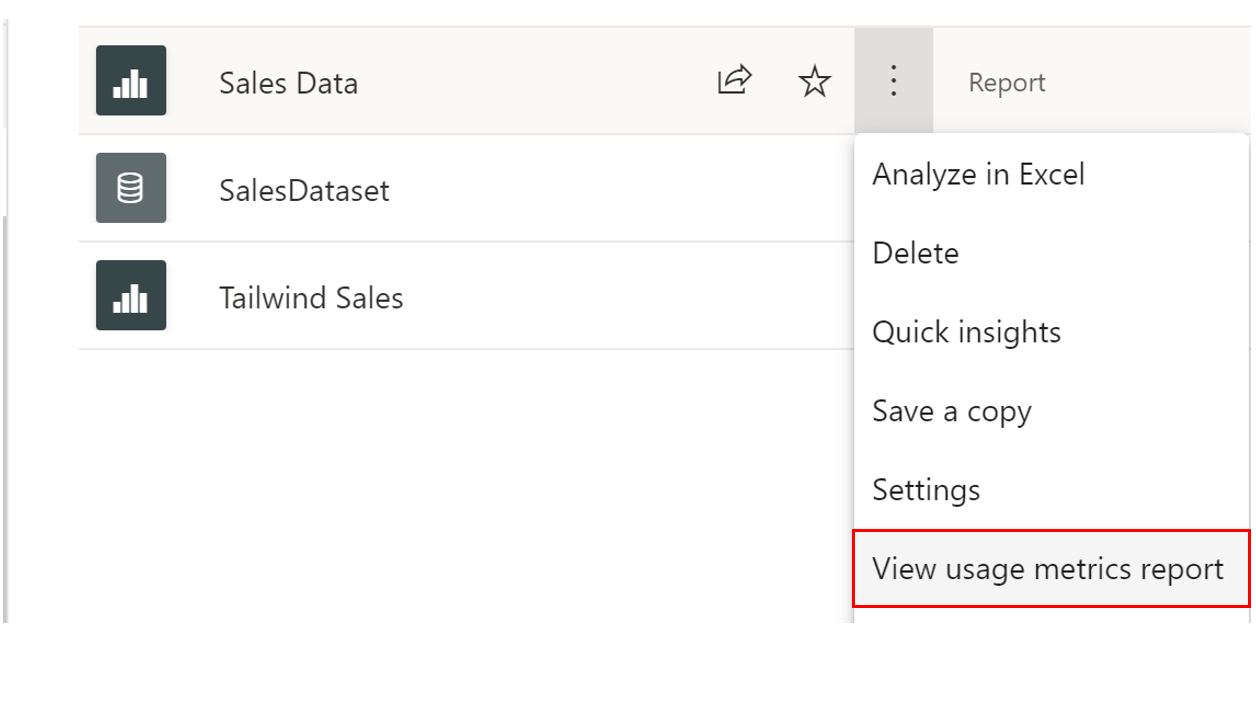

When the usage metrics report is ready for viewing, you will receive a prompt that will direct you to a dashboard. In the Report usage tab, you can view such details as:

- Viewers per day, Unique viewers per day (which doesn't include users who returned to the same reports multiple times), and Shares per day charts.
- Total Views, Total Viewers, and Total Shares KPI cards.
- Total views and shares ranking (compares how your report is doing in comparison to other reports in the app).
- Views by Users (details about each specific user that viewed the dashboard)

You can also filter by the distribution method of the report (for example, through sharing or from the workspace directly) and platform type (for example, mobile or web).

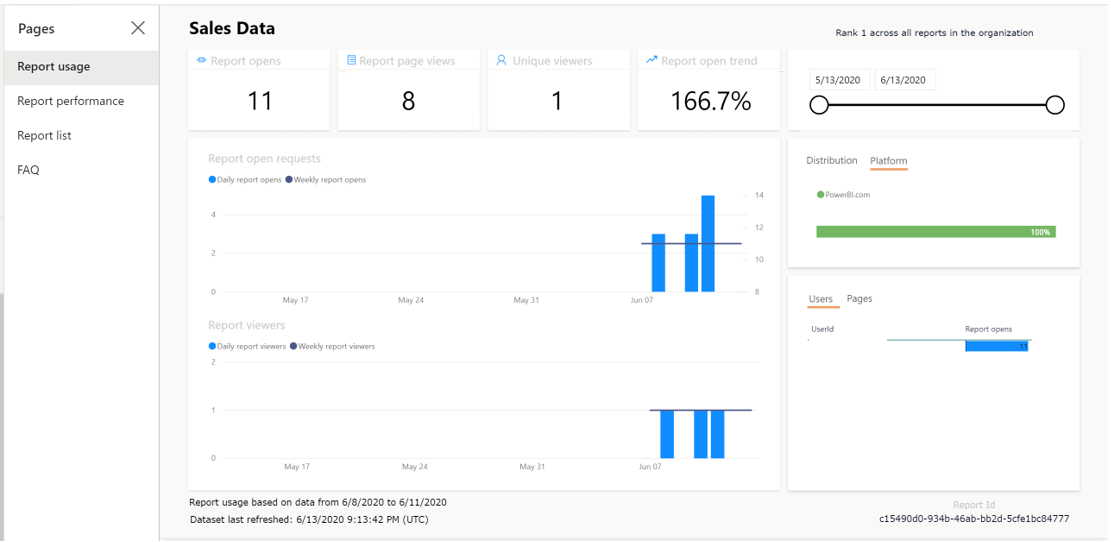


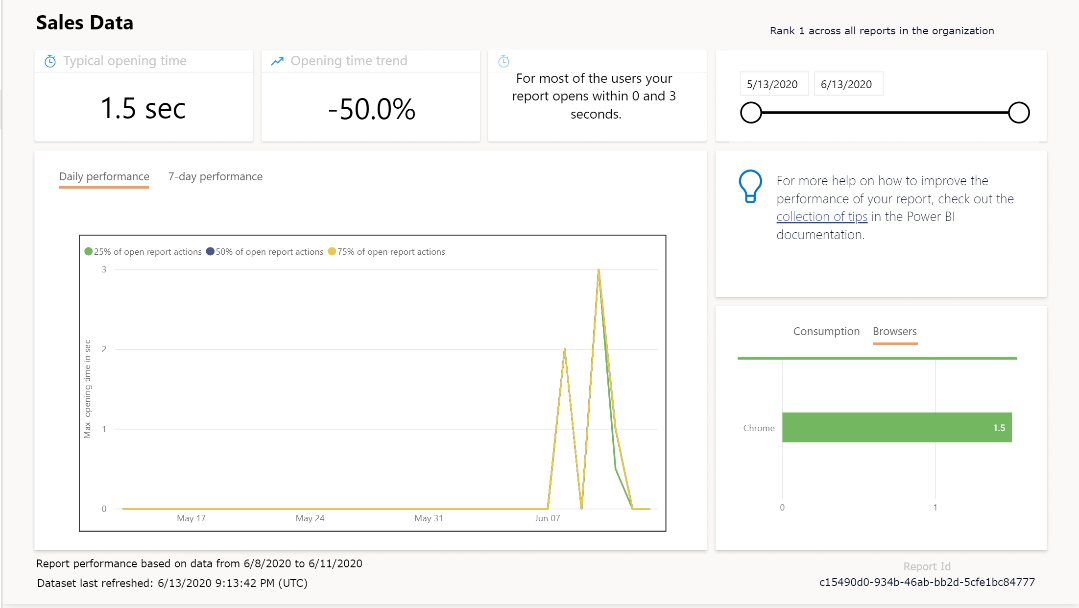

### **Performance Monitoring**

You can also view performance metrics on the Report performance tab, as shown in the following screenshot.

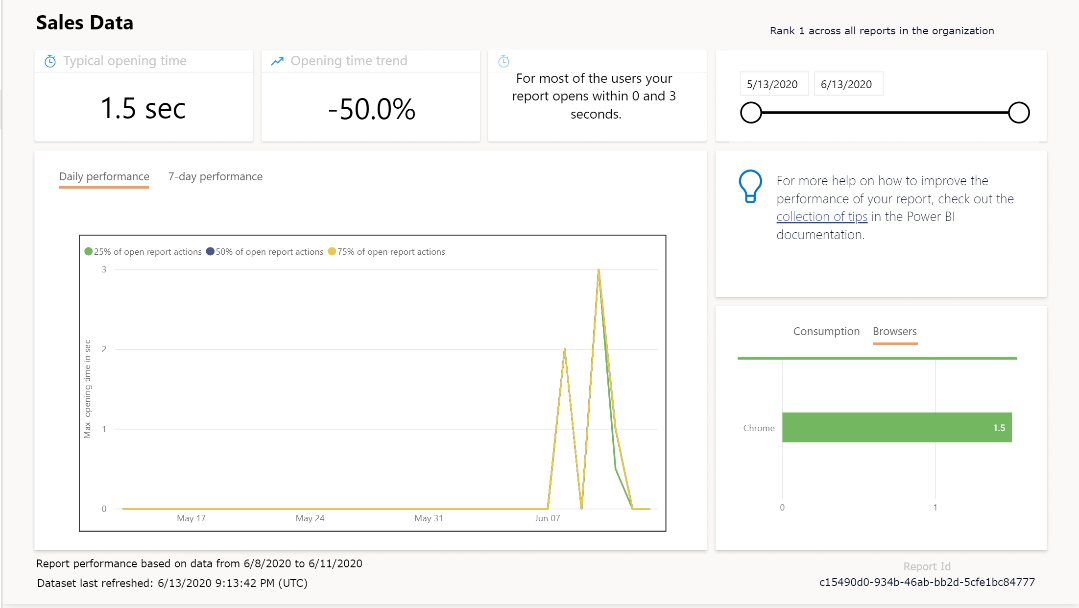

On the Report performance tab, you can view metrics such as:

- Typical opening time - How long it takes, at the fiftieth percentile, to open the report.
- Opening time trend - How the typical opening time changes over time. This metric can tell you how the report is performing as the number of users starts to grow.
- Daily/7-Day Performance charts - Highlight the performance for 10, 50, and 90 percent of the open-report actions every day and over a seven-day period.
- Filters for date, so you can see how the performance changes according to the day.

### **Deployment Pipeline**

The development process is iterative; it typically requires building an initial solution, testing the solution in a different environment, returning to make necessary revisions, and eventually releasing a final product. This process is known as a development life cycle. This process can take place in several different ways and in different environments.

The deployment pipeline feature in Power BI manages content in dashboards, reports, and semantic models between different environments in the development life cycle. With this feature, you can develop and test Power BI content in one centralized location and streamline the process before deploying the final content to your users. This Power BI Premium feature requires you to be a Capacity admin.

#### **Development Environments**

Typically, development and collaboration occur in different stages. Reports and dashboards are built in and iterated on a series of controlled stages, or environments, where several tasks occur:

- **Development**: The location in which dashboard developers or semantic modelers can build new content with other developers. This stage is first in the deployment pipeline.
- **Test**: Where a small group of users and user acceptance testers can see and review new reports, provide feedback, and test the reports with larger semantic models for bugs and data inconsistencies before it goes into production.
- **Production**: Where an expansive user audience can use tested reports that are reliable and accurate. This stage is the final one of the deployment pipeline.

You can choose which one of these development environments that you want to include in your deployment pipeline, according to your business needs. For example, you can choose to only include the Test and Production environments, if necessary.

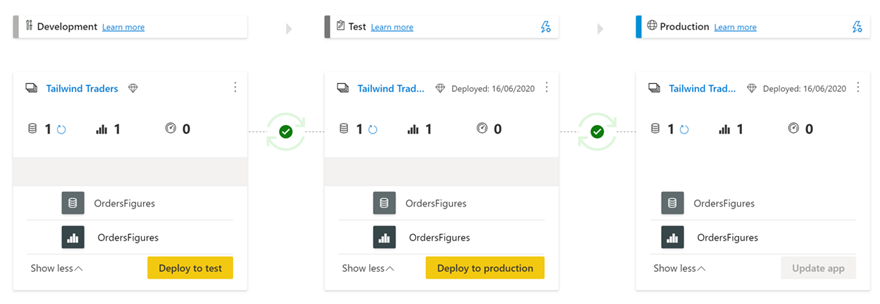

To create your pipeline, assign workspaces to each of these stages to facilitate where your reports and dashboards will be housed during each stage.

On the Data source rules section, you can change the data source (which was used in development) to a new source, which is used for testing the reports (orders.csv in the following example). When you are finished, select Save at the bottom of the card.

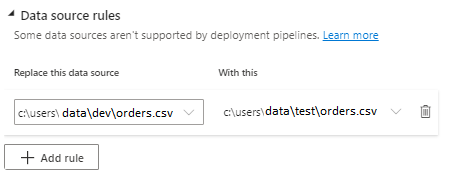

### **Data Lineage**

The Lineage view feature in Power BI allows you to quickly refresh semantic models and see the relationships between the artifacts in a workspace and their external dependencies. Data lineage refers to the path that data takes from the data source to the destination.

#### **"Lineage View"**

The Lineage view is only accessible to Admin, Contributor, and Member roles. Additionally, it requires a Power BI Pro license and is only available for app workspaces. The Lineage view feature in Power BI is crucial because it:
- Simplifies the troubleshooting process because you can see the path that the data takes from source to destination and determine pain points and bottlenecks.
- Allows you to manage your workspaces and observe the impact of a single change in one semantic model to reports and dashboards.
- Saves time by simplifying your task of identifying reports and dashboards that haven't been refreshed.

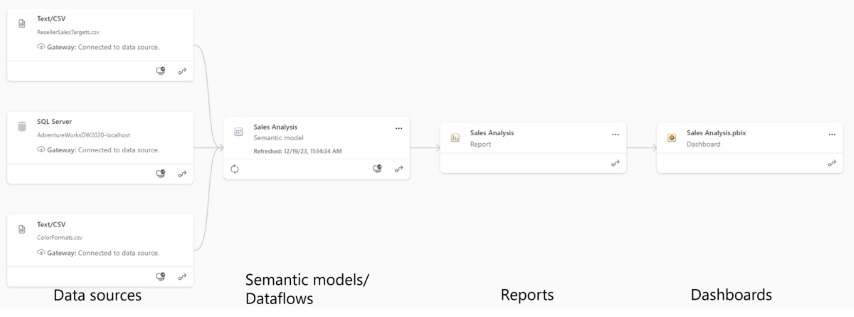

By double-clicking on any card, you can view the metadata, such as the sensitivity, by whom it was configured, the last refresh date, and the names and count of tables within this semantic model, as shown in the following figure.



#### **Impact Analysis**

You can also view the impact of this semantic model across workspaces. On the Impact analysis window, you can see how many workspaces, reports, and dashboards that this semantic model is a part of and how many views that this semantic model has gathered, as shown in the following screenshot.

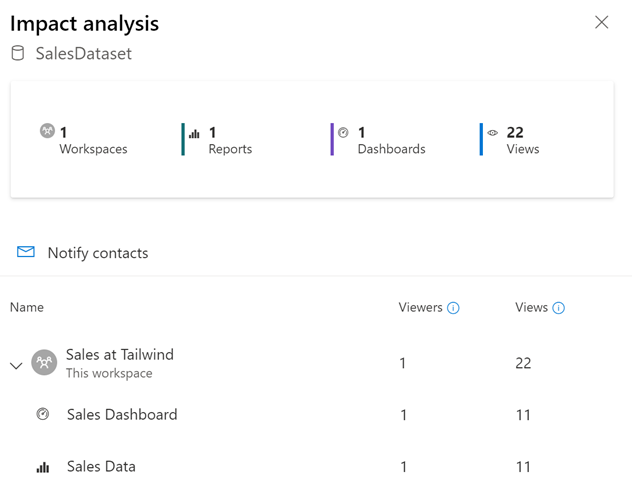

The reports and dashboards cards have similar functionality as the data source and semantic model cards. Selecting a card will bring up a window in which you can view the metadata about the report or dashboard. In this window, you can also go directly to the report or dashboard. You can also enable or disable whether you want to include this report or dashboard within the app.

### **Data Protection**

As enterprises grow, so does their data. Often, strict requirements and regulations must be applied to ensure that this sensitive data is secure. Power BI provides a few different ways to help you accomplish this task:
- Use Microsoft sensitivity labels to label dashboards, reports, semantic models, and dataflows by using the same taxonomy that is used to classify and protect files in Microsoft 365.
- Add more protection measures such as encryption and watermarks when you are exporting the data.
- Use Microsoft Cloud App Security to monitor and investigate activities in Power BI.



#### **Sensitivity Labels**

Sensitivity labels specify which data can be exported. These labels are configured externally to Power BI, and Power BI allows you to quickly use them in your reports and dashboards. These labels allow you to define and protect content, even outside of Power BI. semantic models, dataflows, reports, and dashboards can use this mechanism, and all users in your corporation can use this feature unless exceptions have been defined.

For this example, the following labels have been externally configured, so you can now apply them to the data: None, Personal, General, Confidential, and Highly confidential. 

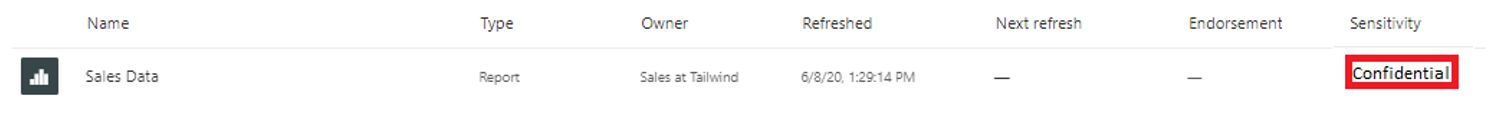

This factor is crucial when you are exporting data. Data that is exported to Microsoft Excel, Microsoft PowerPoint, and PDF files will have sensitivity labels enforced. For instance, if you wanted to export data from Sales Data into an Excel file, if you are an authorized user, you will see the following Excel view when you export into Excel.

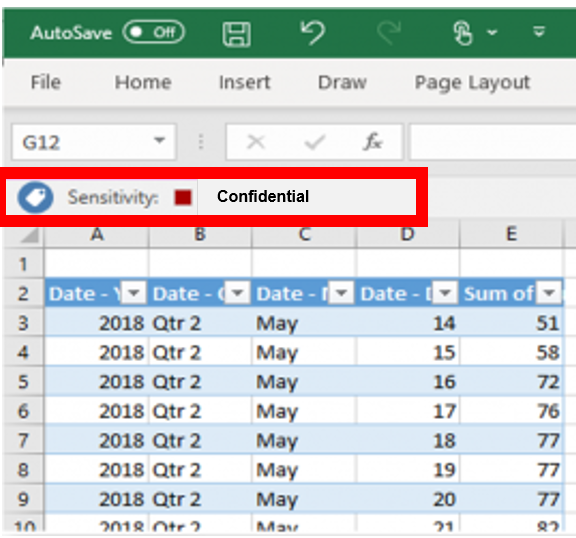

However, if you didn't have established permissions, you would be denied access to see the data. This verification ensures that only appropriate users have access to view the data, which helps make sure that your data is secured.

---
# **DAX** 🟠
---
